#ICT202 - Assignmnet 2
Natural language processing

#1. setup and data loading

1.1 import libraries

In [5]:
# Install the BERTopic library
!pip install bertopic
!pip install gensim

# Import necessary libraries for data manipulation and visualization
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import BERTopic for topic modeling
from bertopic import BERTopic

# Import NLTK for text preprocessing and download necessary data
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab') # Added punkt_tab download

# Imports for text preprocessing
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


1.2 load Raw CSV Files (10-14 June 2023)

In [6]:
# Mount Google Drive to access files stored there
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Import the os module for interacting with the operating system, specifically for listing directory contents
import os

# Walk through the Google Drive directory to list all subdirectories and files
# This helps in verifying file paths and locating data
for dirpath, dirnames, filenames in os.walk('/content/drive/MyDrive/'):
    print(f"Directory: {dirpath}")
    if dirnames:
        print(f"  Subdirectories: {dirnames}")
    if filenames:
        print(f"  Files: {filenames}")

Directory: /content/drive/MyDrive/
  Subdirectories: ['Colab Notebooks']
  Files: ['ENGLISH ESSAY .docx', 'سرعة التفاعلات الكيميائية.pdf', 'دليل المعلم كيمياء الاتزان الكيميائي صف عاشر فصل ثالث.pdf', 'الدرس 1-+2 الوحدة 2.docx', 'Murdoch Under 21 Student Disclaimer Form.pdf', 'Untitled0.ipynb']
Directory: /content/drive/MyDrive/Colab Notebooks
  Subdirectories: ['cuff+less+blood+pressure+estimation', 'Ukraine_Twetter']
  Files: ['ICT202-A2-35523915.ipynb', 'Untitled0.ipynb', 'ICT201_A1_35523915.ipynb', 'Untitled1.ipynb', 'BERTopic notes .ipynb', 'Untitled']
Directory: /content/drive/MyDrive/Colab Notebooks/cuff+less+blood+pressure+estimation
  Subdirectories: ['__MACOSX']
  Files: ['Part_1.mat', 'Part_2.mat', 'Part_3.mat', 'Part_4.mat']
Directory: /content/drive/MyDrive/Colab Notebooks/cuff+less+blood+pressure+estimation/__MACOSX
  Files: ['._Part_2.mat', '._Part_1.mat', '._Part_4.mat', '._Part_3.mat']
Directory: /content/drive/MyDrive/Colab Notebooks/Ukraine_Twetter
  Files: ['202306

In [8]:
# Define the path to the data directory within Google Drive
data_path = Path("/content/drive/MyDrive/Colab Notebooks/Ukraine_Twetter")

# List of CSV files to be loaded
files =  [
    "20230610_UkraineCombinedTweetsDeduped.csv",
    "20230611_UkraineCombinedTweetsDeduped.csv",
    "20230612_UkraineCombinedTweetsDeduped.csv",
    "20230613_UkraineCombinedTweetsDeduped.csv",
    "20230614_UkraineCombinedTweetsDeduped.csv"
]



 1.3 Initial Inspection (head, shape, columns, language counts)

In [9]:
dfs = []

for file_name in files:
    file_path = data_path / file_name
    df = pd.read_csv(file_path)
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

print("First 5 rows of combined_df:")
display(combined_df.head())

print(f"Shape of combined_df: {combined_df.shape}")

First 5 rows of combined_df:


,Unnamed: 0,userid,username,acctdesc,location,following,followers,totaltweets,usercreatedts,tweetid,...,original_tweet_userid,original_tweet_username,in_reply_to_status_id,in_reply_to_user_id,in_reply_to_screen_name,is_quote_status,quoted_status_id,quoted_status_userid,quoted_status_username,extractedts
0,246395,286726350,wmbbkn,Co-Founder @templatenb\n#WordPress #Webdevelop...,Sri Lanka,1217,649,9261,2011-04-23 15:36:33,1667320672115195905,...,0,NaN,0,0,NaN,False,0,0,NaN,2023-06-10 00:33:17.122334
1,246396,1596188689260068864,MilitarPlus,MP+ Proyecto de noticias y narración digital e...,NaN,119,182,3184,2022-11-25 17:07:19,1667320672140541954,...,0,NaN,0,0,NaN,False,0,0,NaN,2023-06-10 00:24:55.688707
2,246397,798770586784702464,pinterpolitik,Official Account of https://t.co/2o04QWs0Up\nh...,"Jakarta, Indonesia",102,13512,17121,2016-11-16 06:12:03,1667320673847635968,...,0,NaN,0,0,NaN,False,0,0,NaN,2023-06-10 00:09:50.369858
3,246398,1618615758,rien4djri,Syria - Progress Posts,NaN,703,1389,97832,2013-07-24 21:16:15,1667320674065711105,...,0,NaN,0,0,NaN,False,0,0,NaN,2023-06-10 00:33:17.116497
4,246399,1282574131599486977,ripetvnews,Latest and Breaking News and Updates from all ...,NaN,4,215,5198,2020-07-13 07:16:00,1667320675659575296,...,0,NaN,0,0,NaN,False,0,0,NaN,2023-06-10 00:33:17.110674


Shape of combined_df: (479366, 29)


In [10]:
# 2. CLEAN + MAKE clean_tweets
processed_df = combined_df.copy()

if 'language' in processed_df.columns:
    processed_df = processed_df.dropna(subset=['language'])
    processed_df = processed_df[processed_df['language'].str.lower() == 'en']

processed_df = processed_df.dropna(subset=['text'])
processed_df = processed_df.drop_duplicates(subset=['text'])
processed_df = processed_df[processed_df['text'].str.len() > 20]

if len(processed_df) > 10000:
    processed_df = processed_df.sample(n=10000, random_state=42)

clean_tweets = processed_df[['text']].rename(columns={'text': 'clean_text'})
print(clean_tweets.head())

                                               clean_text
102138  @NEWSMAX I, SGT KIM US EMPEROR QUANTUM POST US...
216021  Ukraine's Unsung Heroes: Stories from the Fron...
21574   @Sytheruk #RussiaBlewTheDam and committed ecoc...
456732  "The drones watched Anitin set off into no-man...
295172    #Quebec #Canada history https://t.co/11FInuZO8y


In [11]:
# 3. TEXT PREPROCESSING
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
import re

stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z]', ' ', text)
    words = word_tokenize(text)
    words = [ps.stem(w) for w in words if w not in stop_words and len(w) > 1]
    return ' '.join(words)

clean_tweets['processed_text'] = clean_tweets['clean_text'].apply(preprocess_text)

# docs for BERTopic and TF-IDF
docs = clean_tweets['processed_text'].tolist()


#2.Exploratory Data Analysis (EDA)

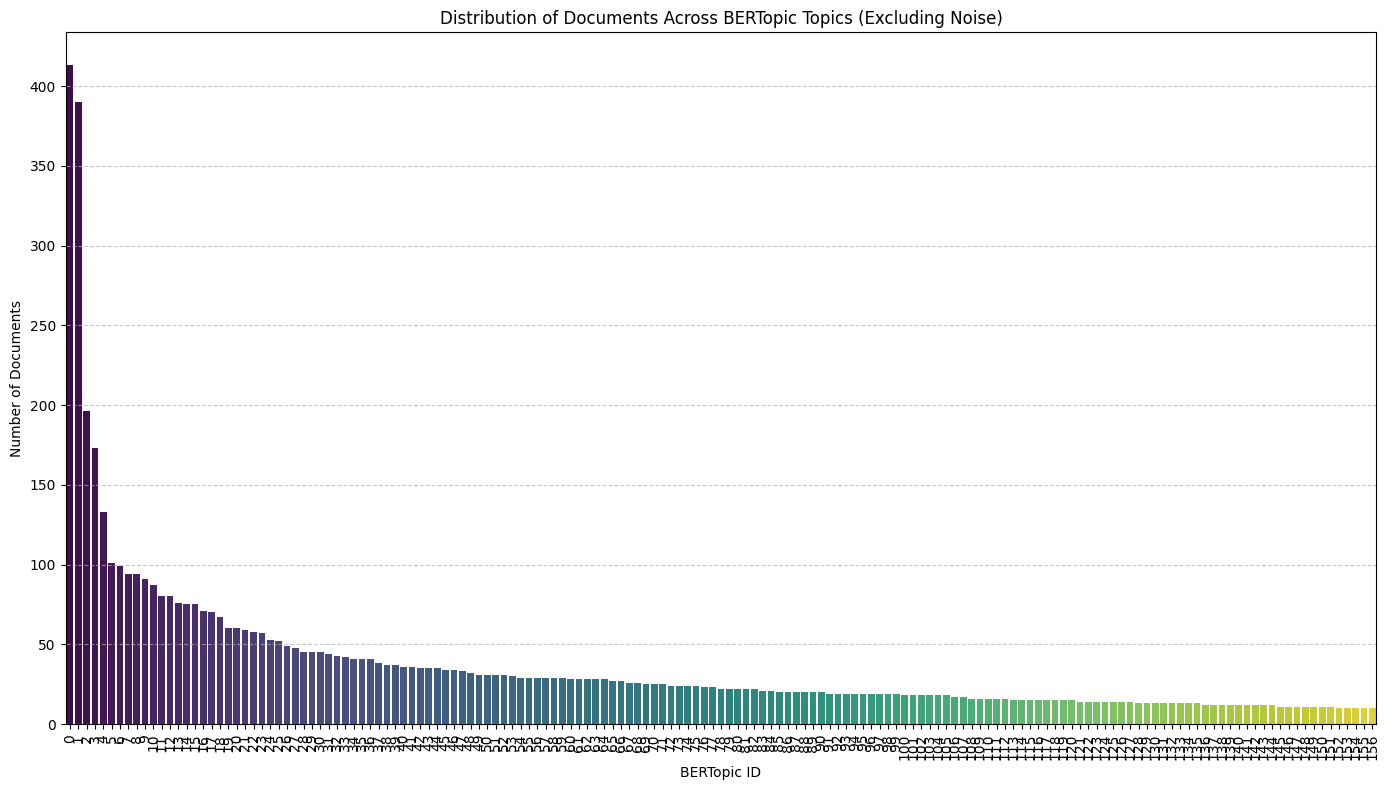

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get topic information from BERTopic model
topic_info_df = topic_model.get_topic_info()

# Filter out the noise topic (-1)
# The 'Count' column usually represents the number of documents in each topic
filtered_topic_counts = topic_info_df[topic_info_df.Topic != -1].sort_values(by="Count", ascending=False)

# Visualize BERTopic topic frequencies
plt.figure(figsize=(14, 8))
sns.barplot(x=filtered_topic_counts.Topic, y=filtered_topic_counts.Count, palette='viridis')
plt.xlabel('BERTopic ID')
plt.ylabel('Number of Documents')
plt.title('Distribution of Documents Across BERTopic Topics (Excluding Noise)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [17]:
vprocessed_df = combined_df.copy()

# language filter
if 'language' in processed_df.columns:
    processed_df = processed_df.dropna(subset=['language'])
    processed_df = processed_df[processed_df['language'].str.lower() == 'en']
else:
    print("Warning: 'language' column not found. Skipping language filtering.")

# drop NaNs and duplicates in text
processed_df = processed_df.dropna(subset=['text'])
processed_df = processed_df.drop_duplicates(subset=['text'])

# remove short tweets
processed_df = processed_df[processed_df['text'].str.len() > 20]

# sample at most 10k
if len(processed_df) > 10000:
    processed_df = processed_df.sample(n=10000, random_state=42)

# final clean_tweets
clean_tweets = processed_df[['text']].rename(columns={'text': 'clean_text'})

print(f"Original combined_df shape: {combined_df.shape}")
print(f"Processed clean_tweets shape: {clean_tweets.shape}")
display(clean_tweets.head())


Original combined_df shape: (479366, 29)
Processed clean_tweets shape: (10000, 1)


,clean_text
102138,"@NEWSMAX I, SGT KIM US EMPEROR QUANTUM POST US..."
216021,Ukraine's Unsung Heroes: Stories from the Fron...
21574,@Sytheruk #RussiaBlewTheDam and committed ecoc...
456732,"""The drones watched Anitin set off into no-man..."
295172,#Quebec #Canada history https://t.co/11FInuZO8y


# 3. Data Cleaning and preprocessing

- data preprocessing:
1. fillterting English tweets
2. removing duplicates and delete short tweets
3. randomaly samppling 10,000 tweets
4. renaming 'text' to 'clean_text'
5. display the dataframe

### Text Preprocessing Steps:
1.  **Case Folding**: Convert all text to lowercase.
2.  **Remove Non-Alphabetic Characters**: Remove numbers, punctuation, and other non-alphabetic symbols.
3.  **Tokenization**: Split sentences into individual words.
4.  **Remove Stop Words**: Eliminate common words (e.g., 'the', 'is', 'a') that typically do not carry significant meaning.
5.  **Stemming**: Reduce words to their root form (e.g., 'running' -> 'run').

In [15]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
import re

stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z]', ' ', text)
    words = word_tokenize(text)
    words = [ps.stem(w) for w in words if w not in stop_words and len(w) > 1]
    return ' '.join(words)

# Apply preprocessing to create the 'processed_text' column
clean_tweets['processed_text'] = clean_tweets['clean_text'].apply(preprocess_text)

# Convert the 'processed_text' column from the preprocessed DataFrame into a list of documents
# This list will be the input for the BERTopic model
docs = clean_tweets['processed_text'].tolist()

# Initialize the BERTopic model
#   language='english': Specifies the language model to use for embeddings (Sentence-BERT).
#   calculate_probabilities=True: Enables the calculation of topic probabilities for each document.
#   verbose=True: Provides detailed output during the model's training process.
topic_model = BERTopic(language = 'english', calculate_probabilities = True, verbose = True)

# Fit the BERTopic model to the documents and transform them to get topic assignments and probabilities
#   topics: A list of topic assignments for each document (-1 typically means outlier).
#   probs: A list of probabilities for each document belonging to its assigned topic.
topics, probs = topic_model.fit_transform(docs)

2026-03-24 10:08:21,045 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

2026-03-24 10:11:59,273 - BERTopic - Embedding - Completed ✓
2026-03-24 10:11:59,274 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-24 10:12:44,743 - BERTopic - Dimensionality - Completed ✓
2026-03-24 10:12:44,744 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-24 10:13:00,275 - BERTopic - Cluster - Completed ✓
2026-03-24 10:13:00,283 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-24 10:13:00,668 - BERTopic - Representation - Completed ✓


In [18]:
# Print a header for clarity
print("Unique languages and their counts in combined_df:\n")
# Display the count of each unique language in the 'language' column of the combined_df
# This helps in understanding the distribution of languages in the dataset
print(combined_df['language'].value_counts())

Unique languages and their counts in combined_df:

language
en     238160
es     102177
fr      28105
it      26892
de      25682
        ...  
or          6
ug          5
hy          4
sd          4
ckb         1
Name: count, Length: 63, dtype: int64


In [19]:
print(combined_df.columns)

Index(['Unnamed: 0', 'userid', 'username', 'acctdesc', 'location', 'following',
       'followers', 'totaltweets', 'usercreatedts', 'tweetid',
       'tweetcreatedts', 'retweetcount', 'text', 'hashtags', 'language',
       'coordinates', 'favorite_count', 'is_retweet', 'original_tweet_id',
       'original_tweet_userid', 'original_tweet_username',
       'in_reply_to_status_id', 'in_reply_to_user_id',
       'in_reply_to_screen_name', 'is_quote_status', 'quoted_status_id',
       'quoted_status_userid', 'quoted_status_username', 'extractedts'],
      dtype='object')


In [20]:
topic_model.get_topic_info(10)

,Topic,Count,Name,Representation,Representative_Docs
0,10,87,10_video_russiawar_ukrainenew_modernwarfar,"[video, russiawar, ukrainenew, modernwarfar, u...",[ukrain russia war video support ukrain slava ...


In [22]:
# Get general information about the first 10 topics
# The argument '10' typically means to show information for up to topic 9 (0-indexed) or a number of topics.
# If no argument is passed, it returns info for all topics.
# Displaying head() to limit output if there are many topics.
display(topic_model.get_topic_info().head(10))

# Get the specific words and their weights for topic 0
# This provides a more detailed look at the terms that define topic 0.
print("\nWords for Topic 0:")
display(topic_model.get_topic(0))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4217,-1_russia_ukrain_co_http,"[russia, ukrain, co, http, putin, russian, war...",[russophobia word invent putin make russian be...
1,0,413,0_trump_maga_trumparraign_gop,"[trump, maga, trumparraign, gop, indict, donal...",[occupydemocrat mari trump maryltrump could on...
2,1,390,1_dam_flood_kakhovka_water,"[dam, flood, kakhovka, water, kherson, evacu, ...",[sick russianarmi sadist flood peopl home puti...
3,2,196,2_trudeau_canada_justintrudeau_canadian,"[trudeau, canada, justintrudeau, canadian, jus...",[surpris visit ukrain canadian prime minist ju...
4,3,173,3_nato_membership_vilniu_sweden,"[nato, membership, vilniu, sweden, summit, sec...",[faster mr jensstoltenberg nato next summit na...
5,4,133,4_rih_injur_kill_kryvyi,"[rih, injur, kill, kryvyi, wound, build, missi...",[least three peopl kill injur earli tuesday du...
6,5,101,5_ukrainerussiawar_ukrainewar_ukrainecounterof...,"[ukrainerussiawar, ukrainewar, ukrainecountero...",[worldonalert advertis anoth wunderwaff wonder...
7,6,99,6_berlusconi_silvio_silvioberlusconi_itali,"[berlusconi, silvio, silvioberlusconi, itali, ...",[watch silvio berlusconi ex leader itali die h...
8,7,94,7_donetsk_liber_villag_forc,"[donetsk, liber, villag, forc, oblast, advanc,...",[ukrainian arm forc liber settlement blagodatn...
9,8,94,8_russiaisaterroristst_russiablewthedam_russia...,"[russiaisaterroristst, russiablewthedam, russi...",[mobik russiaislos russiaisaterroristst russia...



Words for Topic 0:


[('trump', np.float64(0.062203248884881615)),
 ('maga', np.float64(0.022925445447061387)),
 ('trumparraign', np.float64(0.017477488242871014)),
 ('gop', np.float64(0.017054017487470857)),
 ('indict', np.float64(0.015570959971987403)),
 ('donald', np.float64(0.013098585765391735)),
 ('document', np.float64(0.01180923763697458)),
 ('biden', np.float64(0.011778544873473044)),
 ('republican', np.float64(0.011531210427162165)),
 ('democrat', np.float64(0.010411632264086217))]

#4. Feature representation TF-IDF Analysis
TF-IDF (Term Frequency-Inverse Document Frequency) is a numerical statistic that is intended to reflect how important a word is to a document in a collection or corpus.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
# min_df ignores terms that have a document frequency strictly lower than the given threshold
# max_df ignores terms that have a document frequency strictly higher than the given threshold
tfidf_vectorizer = TfidfVectorizer(min_df=5, max_df=0.8)

# Fit and transform the documents to get the TF-IDF matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(docs)

# Get feature names (words) from the vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"Shape of TF-IDF matrix: {tfidf_matrix.shape}")
print(f"Number of unique features (words): {len(feature_names)}")

# Display the top TF-IDF scores for a sample document (e.g., the first document)
print("\nTop TF-IDF words for the first document:")
document_index = 0
feature_index = tfidf_matrix[document_index, :].nonzero()[1]
tfidf_scores = zip(feature_index, [tfidf_matrix[document_index, x] for x in feature_index])
sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)

for word_index, score in sorted_scores[:10]: # Display top 10 words
    print(f"  {feature_names[word_index]}: {score:.4f}")

Shape of TF-IDF matrix: (10000, 4501)
Number of unique features (words): 4501

Top TF-IDF words for the first document:
  newsmax: 0.5050
  kim: 0.2426
  unitedn: 0.2374
  korea: 0.2256
  congress: 0.2184
  colombia: 0.2147
  accept: 0.2114
  brazil: 0.2114
  dubai: 0.2049
  venezuela: 0.2041


#5. K-Means topic modelling

Apply the K-Means clustering algorithm to the TF-IDF matrix to group tweets into 5 clusters.


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Ensure 'docs' is available. 'docs' is already defined in a previous cell as clean_tweets['processed_text'].tolist()

# 1. Re-initialize TF-IDF Vectorizer to ensure tfidf_matrix is defined
tfidf_vectorizer = TfidfVectorizer(min_df=5, max_df=0.8)

# 2. Fit and transform the documents to get the TF-IDF matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(docs)

print(f"Shape of TF-IDF matrix: {tfidf_matrix.shape}")
print(f"Number of unique features (words): {len(tfidf_vectorizer.get_feature_names_out())}")

# Now, apply K-Means clustering
# 2. Instantiate a KMeans object with n_clusters=5, random_state=42, and n_init='auto'
kmeans_model = KMeans(n_clusters=5, random_state=42, n_init='auto')

# 3. Fit the K-Means model to the tfidf_matrix
kmeans_model.fit(tfidf_matrix)

# 4. Get the cluster labels for each document
cluster_labels = kmeans_model.labels_

# 5. Add these cluster labels as a new column named 'kmeans_cluster' to the clean_tweets DataFrame
clean_tweets['kmeans_cluster'] = cluster_labels

print("\nK-Means clustering applied and labels added to 'clean_tweets' DataFrame.")
display(clean_tweets.head())

Shape of TF-IDF matrix: (10000, 4501)
Number of unique features (words): 4501

K-Means clustering applied and labels added to 'clean_tweets' DataFrame.


,clean_text,kmeans_cluster
102138,"@NEWSMAX I, SGT KIM US EMPEROR QUANTUM POST US...",0
216021,Ukraine's Unsung Heroes: Stories from the Fron...,1
21574,@Sytheruk #RussiaBlewTheDam and committed ecoc...,2
456732,"""The drones watched Anitin set off into no-man...",0
295172,#Quebec #Canada history https://t.co/11FInuZO8y,0


# 5. Analyze K-Means Clusters

Analyze the centroids of the K-Means clusters to identify the most representative words for each cluster, thus defining the topics found. Display the top words for each cluster.


In [25]:
import numpy as np

# 1. Get the cluster centroids
cluster_centroids = kmeans_model.cluster_centers_

# 2. Get the feature names (words) from the TF-IDF vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Number of top words to display for each cluster
num_top_words = 10

print(f"\nTop {num_top_words} words for each of the 5 K-Means Clusters:\n")

# 3. For each cluster centroid, identify the top words
for i, centroid in enumerate(cluster_centroids):
    # Sort the feature names by their weights in the centroid in descending order
    sorted_word_indices = centroid.argsort()[::-1]

    # Get the top words and their scores
    top_words = [feature_names[idx] for idx in sorted_word_indices[:num_top_words]]
    top_scores = [centroid[idx] for idx in sorted_word_indices[:num_top_words]]

    # 4. Print these top words for each cluster
    print(f"Cluster {i}:")
    for j in range(num_top_words):
        print(f"  - {top_words[j]} (Score: {top_scores[j]:.4f})")
    print("\n")


Top 10 words for each of the 5 K-Means Clusters:

Cluster 0:
  - co (Score: 0.0526)
  - http (Score: 0.0524)
  - ukrain (Score: 0.0437)
  - russia (Score: 0.0392)
  - war (Score: 0.0147)
  - amp (Score: 0.0144)
  - us (Score: 0.0131)
  - nato (Score: 0.0131)
  - standwithukrain (Score: 0.0122)
  - canada (Score: 0.0118)


Cluster 1:
  - bakhmut (Score: 0.2334)
  - kyiv (Score: 0.1791)
  - canada (Score: 0.1518)
  - tiktok (Score: 0.1207)
  - ukrain (Score: 0.1113)
  - russian (Score: 0.0846)
  - http (Score: 0.0695)
  - co (Score: 0.0695)
  - ukrainian (Score: 0.0680)
  - russia (Score: 0.0666)


Cluster 2:
  - putin (Score: 0.0898)
  - russiaisaterroristst (Score: 0.0860)
  - http (Score: 0.0421)
  - co (Score: 0.0420)
  - russia (Score: 0.0371)
  - ukrain (Score: 0.0297)
  - war (Score: 0.0284)
  - russian (Score: 0.0220)
  - amp (Score: 0.0201)
  - famili (Score: 0.0189)


Cluster 3:
  - ukrain (Score: 0.0819)
  - ukrainerussiawar (Score: 0.0649)
  - co (Score: 0.0648)
  - http (Sc

#6. Visualize Cluster Sizes

Generate a bar chart to visualize the distribution of documents across the identified K-Means clusters, including a legend.


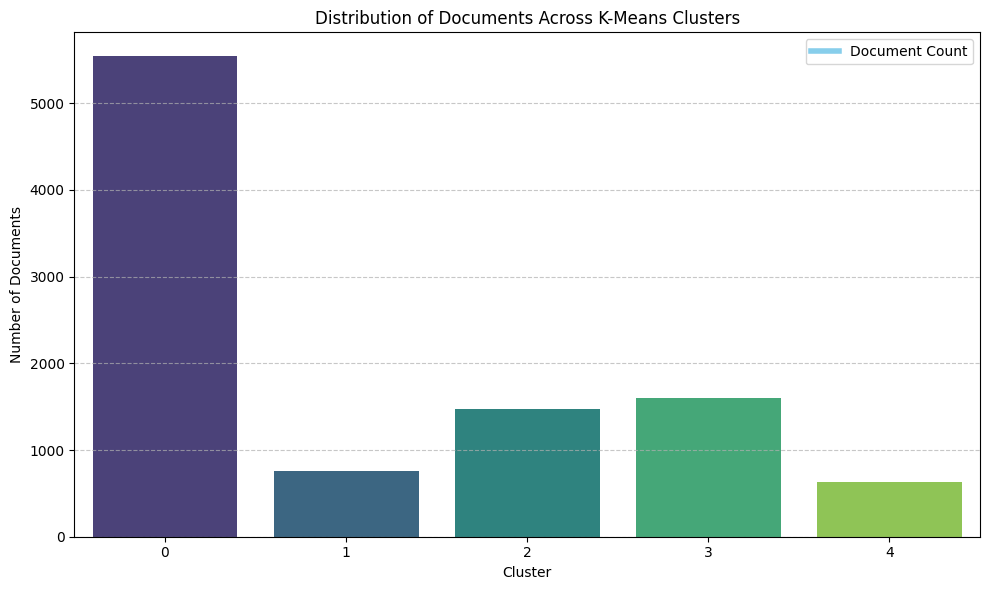

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the count of documents in each cluster
cluster_counts = clean_tweets['kmeans_cluster'].value_counts().sort_index()

# 2. Create a bar chart to visualize these cluster counts
plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')

# 3. Label the x-axis as 'Cluster' and the y-axis as 'Number of Documents'
plt.xlabel('Cluster')
plt.ylabel('Number of Documents')

# 4. Add a title to the chart
plt.title('Distribution of Documents Across K-Means Clusters')

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=0)

# Add a legend (though for a single bar chart, it might be redundant, but as per instruction)
# Create a dummy legend handle as sns.barplot does not directly provide one for value_counts()
plt.legend(handles=[plt.Line2D([0], [0], color='skyblue', lw=4, label='Document Count')])

# Display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [32]:
from bertopic import BERTopic
from sklearn.cluster import KMeans, DBSCAN

# BERTopic
topic_model = BERTopic()
bertopic_labels, _ = topic_model.fit_transform(docs)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [33]:
pd.Series(bertopic_labels).value_counts()


,count
-1,4321
0,400
1,399
2,196
3,133
...,...
148,10
149,10
150,10
151,10


#topic coherence scores (c_v) for BERTopic, K-Means, and DBSCAN.


In [35]:
!pip install gensim
!pip install bertopic

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary


# --- Ensure clean_tweets has 'processed_text', then define docs, tfidf_matrix, feature_names ---
# Assuming `clean_tweets['clean_text']` is already available from previous steps

# If 'processed_text' is not in clean_tweets, re-create it
if 'processed_text' not in clean_tweets.columns:
    # Import NLTK components for preprocessing if needed
    from nltk.corpus import stopwords
    from nltk.stem import PorterStemmer
    from nltk.tokenize import word_tokenize
    import re

    # Ensure stop_words and ps (PorterStemmer) are defined
    stop_words = set(stopwords.words('english'))
    ps = PorterStemmer()

    def preprocess_text(text):
        text = text.lower()
        text = re.sub(r'[^a-z]', ' ', text)
        words = word_tokenize(text)
        words = [ps.stem(w) for w in words if w not in stop_words and len(w) > 1]
        return ' '.join(words)

    clean_tweets['processed_text'] = clean_tweets['clean_text'].apply(preprocess_text)

docs = clean_tweets['processed_text'].tolist()

# Re-initialize TF-IDF Vectorizer and matrix
tfidf_vectorizer = TfidfVectorizer(min_df=5, max_df=0.8)
tfidf_matrix = tfidf_vectorizer.fit_transform(docs)
feature_names = tfidf_vectorizer.get_feature_names_out()

# --- Re-apply K-Means clustering and add labels to clean_tweets ---
# The number of clusters (5) and random_state (42) were used previously in ab655d1d
kmeans_model = KMeans(n_clusters=5, random_state=42, n_init='auto')
cluster_labels_kmeans = kmeans_model.fit_predict(tfidf_matrix)
clean_tweets['kmeans_cluster'] = cluster_labels_kmeans
cluster_centroids = kmeans_model.cluster_centers_ # Required for KMeans top words

# --- Re-apply DBSCAN clustering and add labels to clean_tweets ---
# eps=0.7 and min_samples=5 were used previously in c272b4fe
dbscan_model = DBSCAN(eps=0.7, min_samples=5)
cluster_labels_dbscan = dbscan_model.fit_predict(tfidf_matrix.toarray())
clean_tweets['dbscan_cluster'] = cluster_labels_dbscan

In [36]:
# --- Gensim coherence setup (from ZETtzyyS8Aac) ---
texts = [doc.split() for doc in docs]
dictionary = Dictionary(texts)

def coherence(top_words):
    cm = CoherenceModel(
        topics=top_words,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    return cm.get_coherence()

num_top_words = 10

In [37]:
# --- BERTopic Coherence ----
# Re-instantiate and fit BERTopic to ensure it's consistent with current `docs`
topic_model = BERTopic(language='english', calculate_probabilities=True, verbose=False)
topics, probs = topic_model.fit_transform(docs)
# Update bertopic_labels for any other uses, though not directly used in coherence calculation loop
bertopic_labels = topics

bertopic_top_words = []
for topic_id in topic_model.get_topic_info().Topic.unique():
    if topic_id != -1:
        words_with_scores = topic_model.get_topic(topic_id)
        bertopic_top_words.append([word for word, score in words_with_scores])

bertopic_top_words = [topic for topic in bertopic_top_words if topic]

if len(bertopic_top_words) > 1:
    bertopic_coherence_score = coherence(bertopic_top_words)
else:
    bertopic_coherence_score = None

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [38]:
# --- K-Means Coherence ---
# Re-create top_words_kmeans_dict as cluster_centroids might have changed after re-applying K-Means
top_words_kmeans_dict = {}
for i, centroid in enumerate(cluster_centroids):
    sorted_word_indices = centroid.argsort()[::-1]
    top_words_kmeans_dict[i] = [feature_names[idx] for idx in sorted_word_indices[:num_top_words]]

kmeans_top_words = list(top_words_kmeans_dict.values())

if len(kmeans_top_words) > 1:
    kmeans_coherence_score = coherence(kmeans_top_words)
else:
    kmeans_coherence_score = Non

In [40]:
# --- DBSCAN Coherence ---
dbscan_top_words = []
unique_dbscan_clusters = clean_tweets['dbscan_cluster'].unique()

valid_dbscan_clusters = [c_id for c_id in unique_dbscan_clusters if c_id != -1 and (clean_tweets['dbscan_cluster'] == c_id).sum() >= 5]

if len(valid_dbscan_clusters) > 0:
    for cluster_id in valid_dbscan_clusters:
        # Create a boolean mask for the current cluster
        cluster_mask = (clean_tweets['dbscan_cluster'] == cluster_id)
        # Apply the mask to tfidf_matrix to get vectors for this cluster
        cluster_tfidf_vectors = tfidf_matrix[cluster_mask.values]
        if cluster_tfidf_vectors.shape[0] > 0:
            cluster_centroid_dbscan = cluster_tfidf_vectors.mean(axis=0).A1
            sorted_word_indices = cluster_centroid_dbscan.argsort()[::-1]
            top_words_for_cluster = [feature_names[idx] for idx in sorted_word_indices if cluster_centroid_dbscan[idx] > 0][:num_top_words]
            if top_words_for_cluster:
                dbscan_top_words.append(top_words_for_cluster)

if len(dbscan_top_words) > 1:
    dbscan_coherence_score = coherence(dbscan_top_words)
else:
    dbscan_coherence_score = None

In [41]:
# --- Display Results ---
coherence_results = pd.DataFrame({
    "Model": ["BERTopic", "KMeans", "DBSCAN"],
    "Coherence (c_v) Score": [bertopic_coherence_score, kmeans_coherence_score, dbscan_coherence_score]
})

display(coherence_results)

,Model,Coherence (c_v) Score
0,BERTopic,0.619309
1,KMeans,0.503920
2,DBSCAN,0.875342


#9. Extract Example Tweets for K-Means Clusters

### Subtask:
For each of the K-Means clusters, retrieve and display a few representative original tweets to provide a qualitative understanding of the cluster content.


**Reasoning**:
To extract representative tweets for each K-Means cluster, I will create a new DataFrame, identify unique clusters, and then iterate through each cluster to retrieve its top words and sample original tweets for display.



In [42]:
import pandas as pd
import numpy as np

# 1. Create a new DataFrame, kmeans_df, by copying clean_tweets
kmeans_df = clean_tweets.copy()

# 2. Ensure the kmeans_cluster column is present in kmeans_df (it was added in a previous step)
# If it wasn't, an error would occur, but based on notebook state, it exists.

# 3. Get the list of unique K-Means cluster IDs
unique_kmeans_clusters = kmeans_df['kmeans_cluster'].unique()
unique_kmeans_clusters.sort()

print("\nRepresentative Tweets for K-Means Clusters:\n")

# Ensure cluster_centroids and feature_names are accessible from previous steps
# (These were generated in cell 38eabbd2)
# If not, they would need to be re-run or passed as arguments.

# 4. For each unique K-Means cluster ID:
for cluster_id in unique_kmeans_clusters:
    print(f"--- K-Means Cluster {cluster_id} ---")

    # b. Retrieve and print the top 10 representative words for the current cluster.
    # This uses the cluster_centroids and feature_names from the 'Analyze K-Means Clusters' step.
    num_top_words = 10 # Defined in previous analysis step
    centroid = cluster_centroids[cluster_id]
    sorted_word_indices = centroid.argsort()[::-1]
    top_words = [feature_names[idx] for idx in sorted_word_indices[:num_top_words]]
    top_scores = [centroid[idx] for idx in sorted_word_indices[:num_top_words]]

    print("Top words:")
    for j in range(num_top_words):
        print(f"  - {top_words[j]} (Score: {top_scores[j]:.4f})")

    # c. Filter kmeans_df to select tweets belonging to the current cluster.
    cluster_tweets_df = kmeans_df[kmeans_df['kmeans_cluster'] == cluster_id]

    # d. Randomly sample 3 to 5 original tweets (clean_text column).
    num_samples = min(len(cluster_tweets_df), 5) # Sample up to 5, or all if less than 5
    if num_samples > 0:
        sampled_tweets = cluster_tweets_df['clean_text'].sample(n=num_samples, random_state=42).tolist()
    else:
        sampled_tweets = []

    # e. Print each of the sampled tweets.
    print("Sample Tweets:")
    if sampled_tweets:
        for i, tweet in enumerate(sampled_tweets):
            print(f"  Sample {i+1}: {tweet}")
    else:
        print("  No tweets found for this cluster.")
    print("\n")


Representative Tweets for K-Means Clusters:

--- K-Means Cluster 0 ---
Top words:
  - co (Score: 0.0526)
  - http (Score: 0.0524)
  - ukrain (Score: 0.0437)
  - russia (Score: 0.0392)
  - war (Score: 0.0147)
  - amp (Score: 0.0144)
  - us (Score: 0.0131)
  - nato (Score: 0.0131)
  - standwithukrain (Score: 0.0122)
  - canada (Score: 0.0118)
Sample Tweets:
  Sample 1: "We want to get a real #result for #Russia. For the sake of this result, we are #ready to continue the #dialogue, but this dialogue must be effective. So far, unfortunately, it is not," he said.
  Sample 2: @Guyfawkeslol #WheresTheMoney .. look in #Ukraine at the firm of Biden&amp;Zelensky, LLC.  
#BidenBribery 
#BidenCrimeFamilyExposed 
#Biden https://t.co/Z1w5t3YaP9
  Sample 3: The #UnitedStates will urgently replace the #Bradleys lost to #Ukraine during the offensive.

Tomorrow, the #US will urgently provide a new $325 million #military aid package, a US Defense Department spokesman said on condition of anonymity.

#Sl

In [44]:
# import numpy as np

# # 1. Calculate the coherence score for the BERTopic model
# # The 'docs' variable contains the preprocessed text documents.
# coherence_score = topic_model.get_topic_coherence(docs)

# # 2. Print the calculated coherence score
print(f"BERTopic Topic Coherence Score: {bertopic_coherence_score:.4f}")

# Note: The 'get_topic_coherence' method is not directly available in this BERTopic version.
# Please refer to cell fc0cdf36 for the correct coherence calculation using Gensim.

BERTopic Topic Coherence Score: 0.6193


### New Function Placeholder

This is where you can add your new function definitions. Placing them after existing utility functions like `preprocess_text` ensures they are defined in a logical and accessible part of the notebook before being called by other operations.

In [45]:
def my_new_function(data):
    """This is a placeholder for your new function."""
    print("New function called with data:", data)
    return data

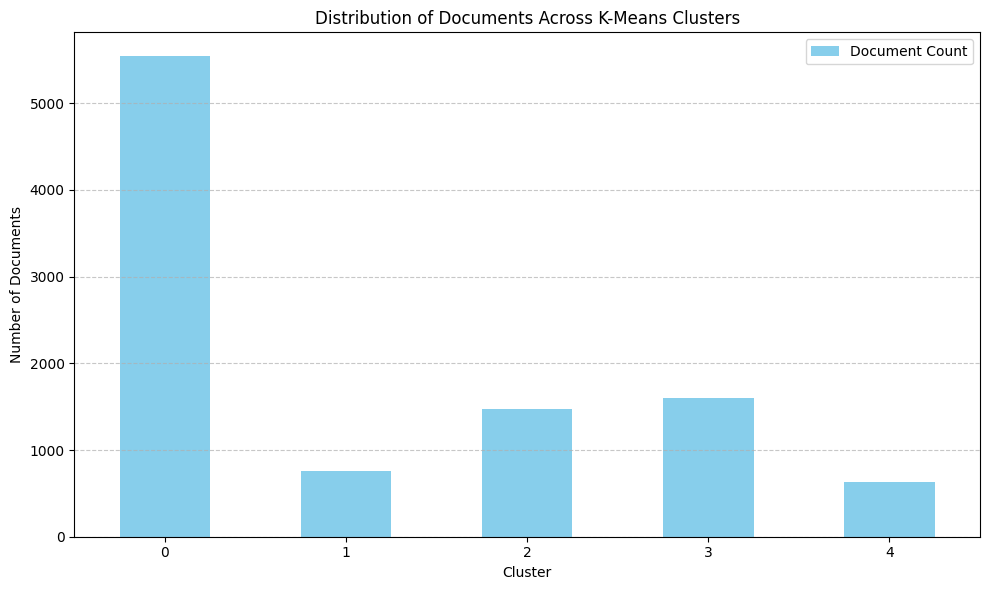

In [46]:
import matplotlib.pyplot as plt

# 1. Calculate the count of documents in each cluster
cluster_counts = clean_tweets['kmeans_cluster'].value_counts().sort_index()

# 2. Create a bar chart to visualize these cluster counts
plt.figure(figsize=(10, 6))
cluster_counts.plot(kind='bar', color='skyblue')

# 3. Label the x-axis as 'Cluster' and the y-axis as 'Number of Documents'
plt.xlabel('Cluster')
plt.ylabel('Number of Documents')

# 4. Add a title to the chart
plt.title('Distribution of Documents Across K-Means Clusters')

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=0)

# Add a legend (though for a single bar chart, it might be redundant, but as per instruction)
plt.legend(['Document Count'])

# Display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

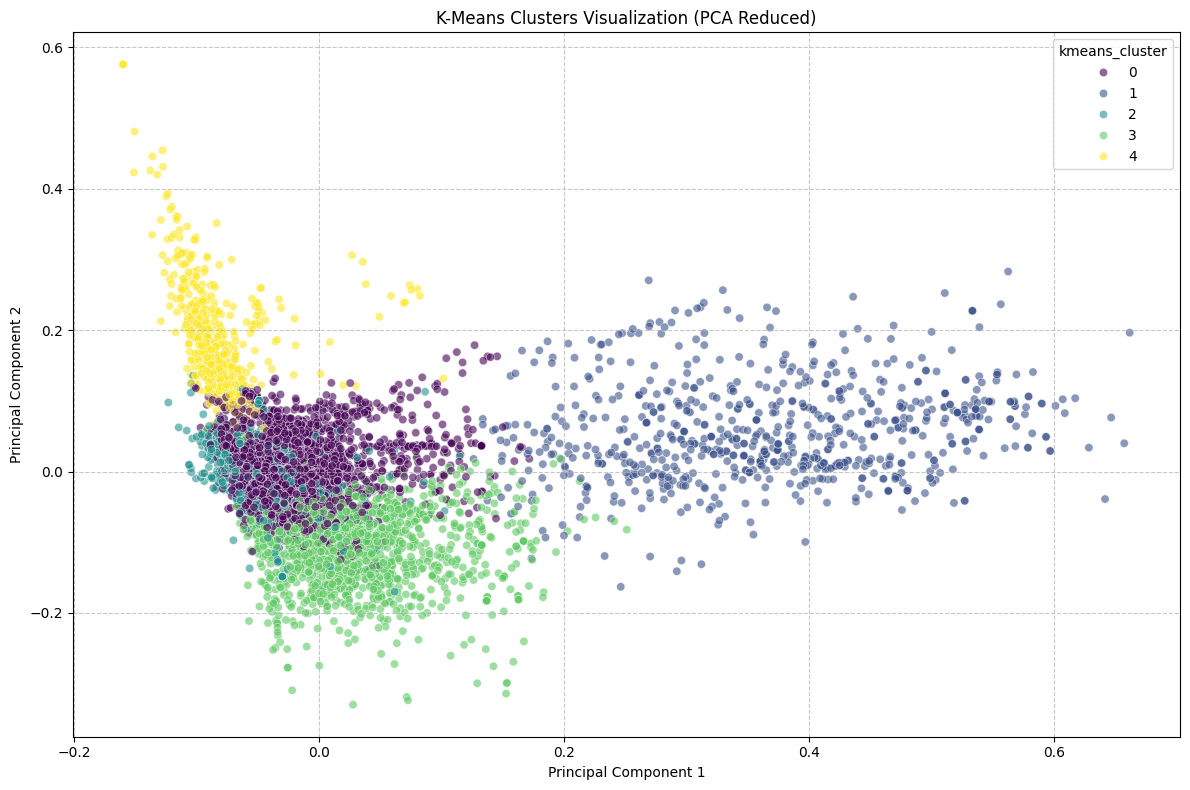

In [47]:
from sklearn.decomposition import PCA

# Reduce the dimensionality of the TF-IDF matrix for visualization
# PCA is chosen for its simplicity and interpretability in showing variance.
pca = PCA(n_components=2, random_state=42)
tfidf_2d = pca.fit_transform(tfidf_matrix.toarray()) # Convert sparse matrix to dense array

# Add the 2D PCA components to the clean_tweets DataFrame for easy plotting
clean_tweets['pca_one'] = tfidf_2d[:, 0]
clean_tweets['pca_two'] = tfidf_2d[:, 1]

# Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='pca_one',
    y='pca_two',
    hue='kmeans_cluster',
    palette='viridis',
    data=clean_tweets,
    legend='full',
    alpha=0.6
)

plt.title('K-Means Clusters Visualization (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 7. Calculate BERTopic Coherence

Calculate and display topic coherence scores for the topics identified by BERTopic. This provides a quantitative measure of topic quality.


In [48]:
from sklearn.cluster import DBSCAN

# 1. Instantiate a DBSCAN object with eps=0.7 and min_samples=5
dbscan_model = DBSCAN(eps=0.7, min_samples=5)

# 2. Fit the DBSCAN model to the tfidf_matrix
# DBSCAN expects a dense matrix if not explicitly handling sparse matrices, so converting is safer
dbscan_model.fit(tfidf_matrix.toarray())

# 3. Get the cluster labels for each document
cluster_labels_dbscan = dbscan_model.labels_

# 4. Add these cluster labels as a new column named 'dbscan_cluster' to the clean_tweets DataFrame
clean_tweets['dbscan_cluster'] = cluster_labels_dbscan

print("DBSCAN clustering applied and labels added to 'clean_tweets' DataFrame.")
display(clean_tweets.head())

DBSCAN clustering applied and labels added to 'clean_tweets' DataFrame.


,clean_text,kmeans_cluster,processed_text,dbscan_cluster,pca_one,pca_two
102138,"@NEWSMAX I, SGT KIM US EMPEROR QUANTUM POST US...",0,newsmax sgt kim us emperor quantum post usa ac...,-1,-0.058165,0.029338
216021,Ukraine's Unsung Heroes: Stories from the Fron...,1,ukrain unsung hero stori front line ukrain rus...,-1,0.173408,-0.123125
21574,@Sytheruk #RussiaBlewTheDam and committed ecoc...,2,sytheruk russiablewthedam commit ecocid kill e...,-1,-0.066832,-0.003073
456732,"""The drones watched Anitin set off into no-man...",0,drone watch anitin set man land step discard r...,-1,-0.033069,0.003468
295172,#Quebec #Canada history https://t.co/11FInuZO8y,0,quebec canada histori http co finuzo,-1,0.061306,0.092699


In [49]:
import numpy as np

# 1. Get the unique cluster labels from the 'dbscan_cluster' column
unique_labels = np.unique(clean_tweets['dbscan_cluster'])

# 2. Calculate the number of clusters, excluding the noise points (labeled as -1)
num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

# 3. Calculate the number of noise points
noise_points = np.sum(clean_tweets['dbscan_cluster'] == -1)

# 4. Calculate the number of documents assigned to each cluster, excluding noise points
cluster_counts_dbscan = clean_tweets['dbscan_cluster'].value_counts().sort_index()

print(f"\nDBSCAN Clustering Analysis:")
print(f"Total number of identified clusters (excluding noise): {num_clusters}")
print(f"Number of noise points: {noise_points}")
print("\nDocument counts per cluster (excluding noise points):")

# Print counts for actual clusters
for cluster_label, count in cluster_counts_dbscan.items():
    if cluster_label != -1:
        print(f"  Cluster {cluster_label}: {count} documents")


DBSCAN Clustering Analysis:
Total number of identified clusters (excluding noise): 62
Number of noise points: 9307

Document counts per cluster (excluding noise points):
  Cluster 0: 5 documents
  Cluster 1: 33 documents
  Cluster 2: 11 documents
  Cluster 3: 19 documents
  Cluster 4: 9 documents
  Cluster 5: 17 documents
  Cluster 6: 40 documents
  Cluster 7: 7 documents
  Cluster 8: 22 documents
  Cluster 9: 13 documents
  Cluster 10: 19 documents
  Cluster 11: 8 documents
  Cluster 12: 15 documents
  Cluster 13: 49 documents
  Cluster 14: 9 documents
  Cluster 15: 5 documents
  Cluster 16: 9 documents
  Cluster 17: 6 documents
  Cluster 18: 8 documents
  Cluster 19: 5 documents
  Cluster 20: 15 documents
  Cluster 21: 7 documents
  Cluster 22: 17 documents
  Cluster 23: 10 documents
  Cluster 24: 6 documents
  Cluster 25: 6 documents
  Cluster 26: 7 documents
  Cluster 27: 14 documents
  Cluster 28: 35 documents
  Cluster 29: 8 documents
  Cluster 30: 22 documents
  Cluster 31: 5 d

# 8. Visualize BERTopic Top Word Distributions

### Subtask:
For each of the main BERTopic topics, visualize the distribution of its top representative words and their scores.

In [50]:
# Make a copy of the combined_df to avoid modifying the original data
processed_df = combined_df.copy()

# 1. Filter to English tweets (assuming 'language' column exists and 'en' is the value)
# Check if the 'language' column exists in the DataFrame
if 'language' in processed_df.columns:
    # Drop rows where 'language' is NaN to ensure accurate filtering
    processed_df = processed_df.dropna(subset=['language'])
    # Filter the DataFrame to keep only English tweets ('en')
    processed_df = processed_df[processed_df['language'].str.lower() == 'en']
else:
    print("Warning: 'language' column not found. Skipping language filtering.")

# 2. Remove duplicates based on the 'text' column
# Drop rows where 'text' is NaN before checking for duplicates
processed_df = processed_df.dropna(subset=['text'])
# Remove duplicate tweets based on their 'text' content
processed_df = processed_df.drop_duplicates(subset=['text'])

# 3. Remove very short tweets (e.g., less than 20 characters)
# Filter out tweets shorter than 20 characters, as they might not provide meaningful topics
processed_df = processed_df[processed_df['text'].str.len() > 20]

# 4. Immediately randomly sample to at most 10,000 tweets
# If the number of processed tweets exceeds 10,000, randomly sample 10,000 for efficiency
if len(processed_df) > 10000:
    processed_df = processed_df.sample(n=10000, random_state=42)

# 5. Keep only clean_text (renaming 'text' column to 'clean_text' and selecting only it)
# Select the 'text' column and rename it to 'clean_text' for clarity
clean_tweets = processed_df[['text']].rename(columns={'text': 'clean_text'})

# Print the shapes of the original and processed DataFrames to show the impact of preprocessing
print(f"Original combined_df shape: {combined_df.shape}")
print(f"Processed clean_tweets shape: {clean_tweets.shape}")
# Display the first few rows of the cleaned tweets
display(clean_tweets.head())

Original combined_df shape: (479366, 29)
Processed clean_tweets shape: (10000, 1)


,clean_text
102138,"@NEWSMAX I, SGT KIM US EMPEROR QUANTUM POST US..."
216021,Ukraine's Unsung Heroes: Stories from the Fron...
21574,@Sytheruk #RussiaBlewTheDam and committed ecoc...
456732,"""The drones watched Anitin set off into no-man..."
295172,#Quebec #Canada history https://t.co/11FInuZO8y



Visualizing top words for the top 10 BERTopic topics:



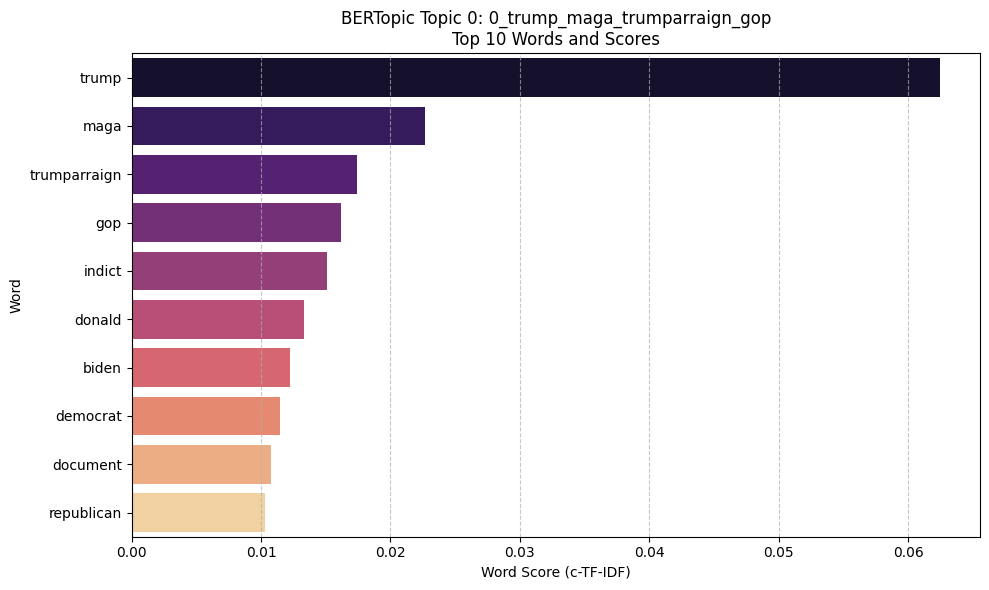

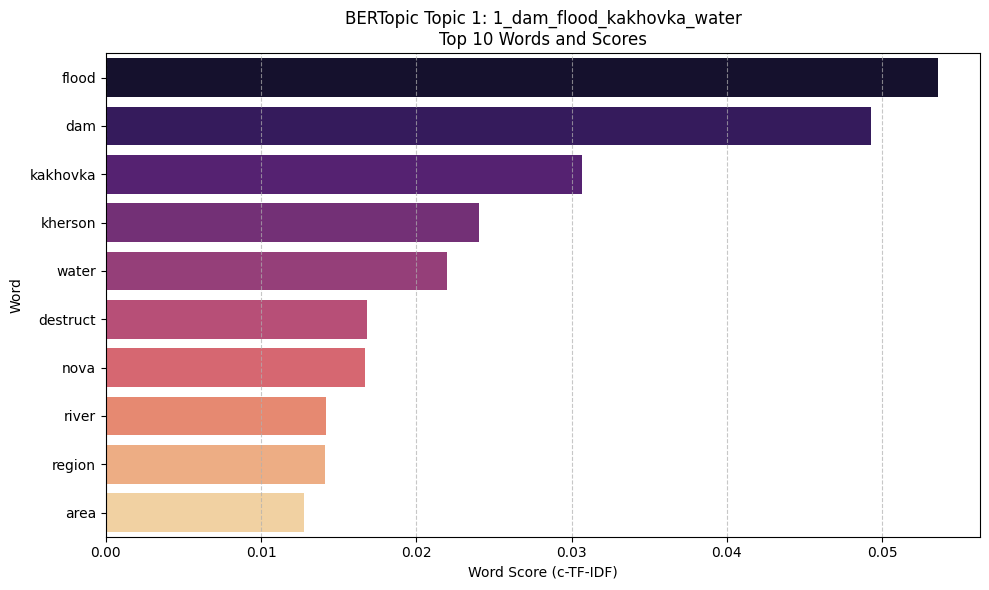

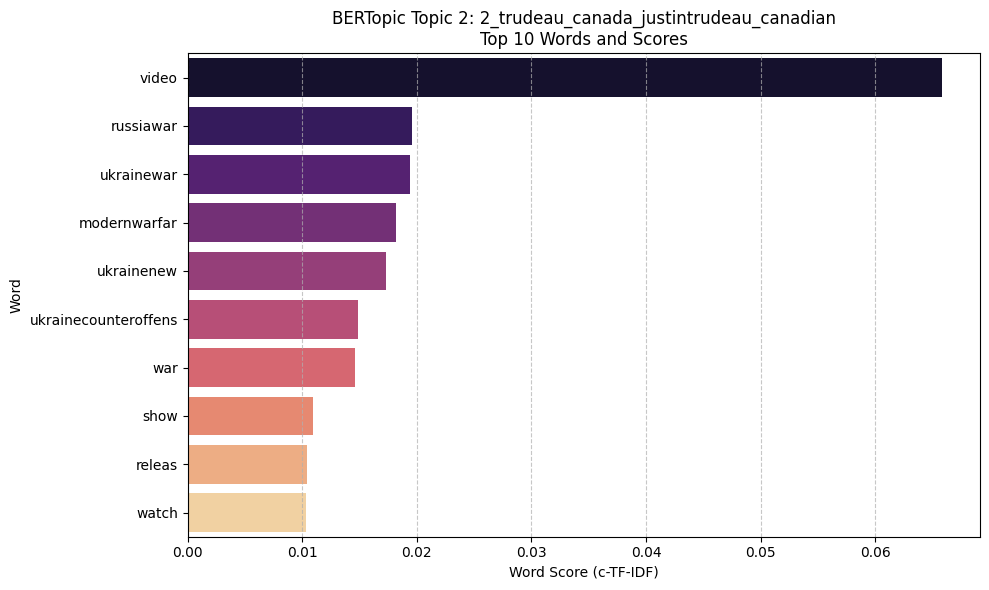

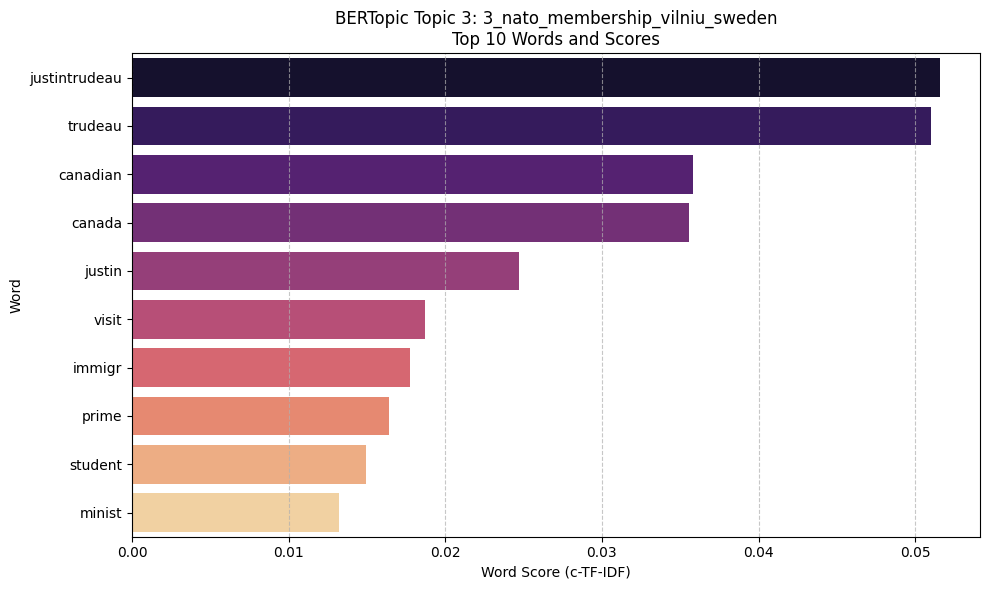

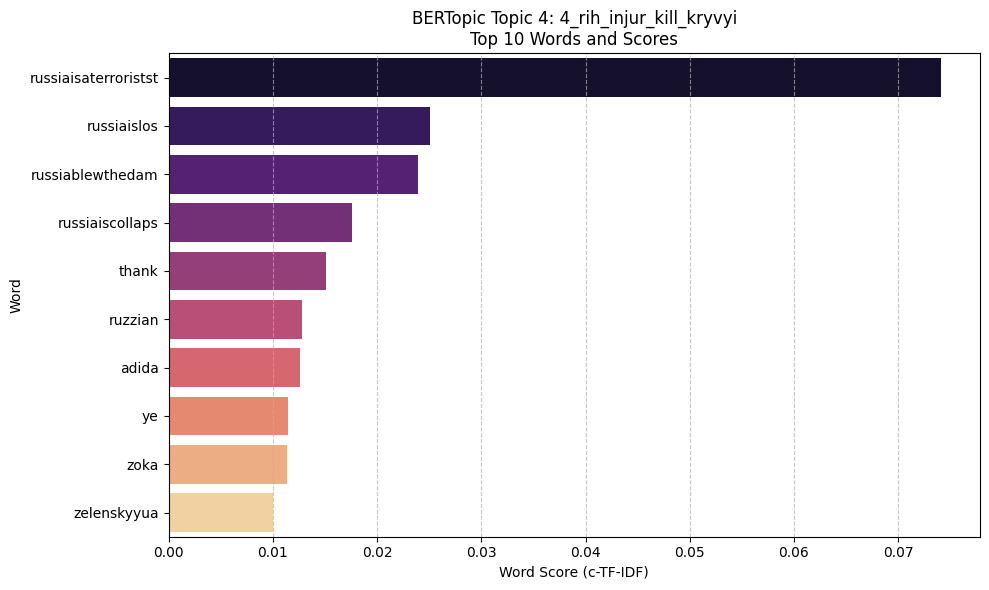

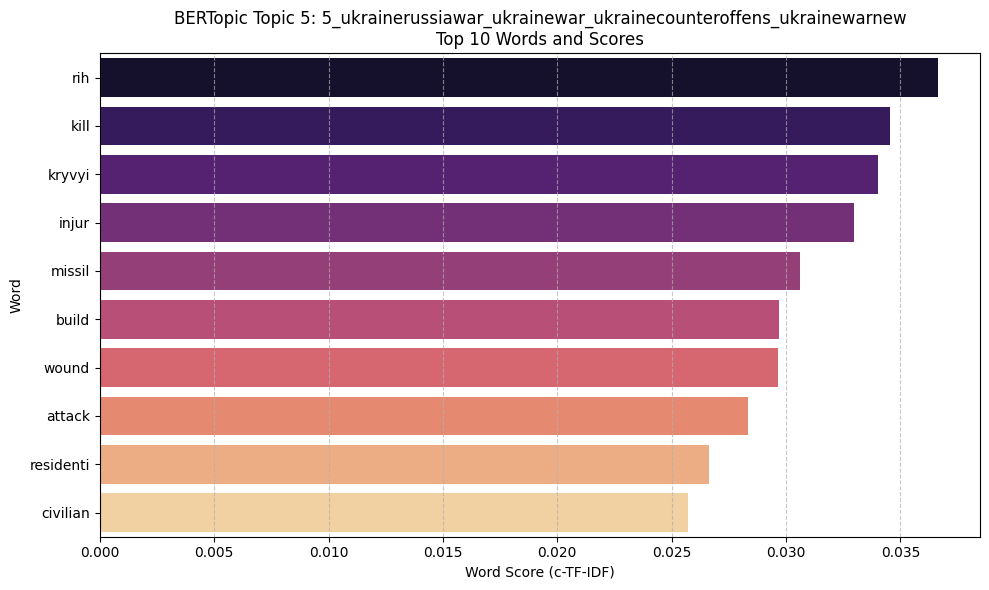

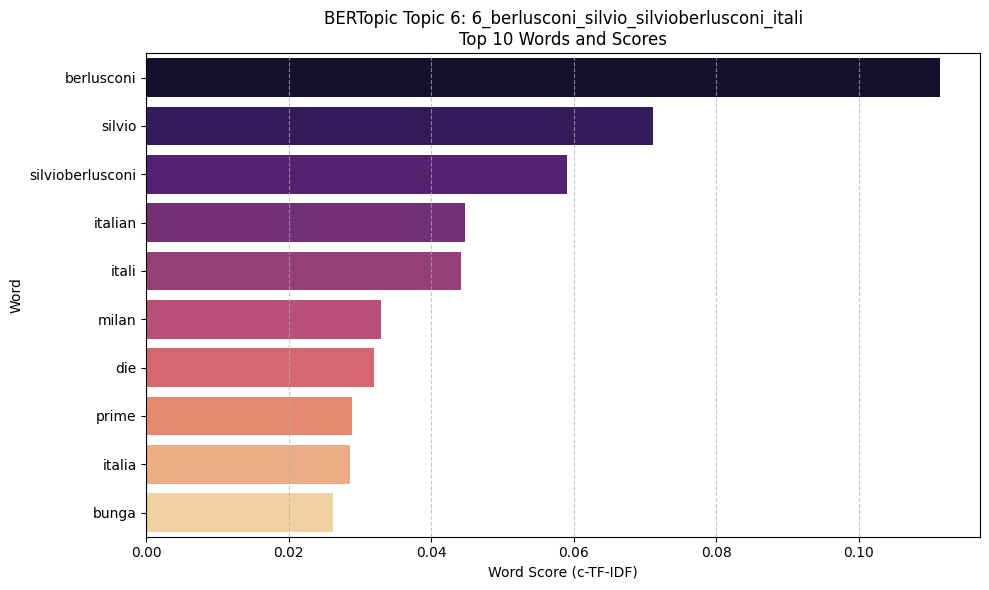

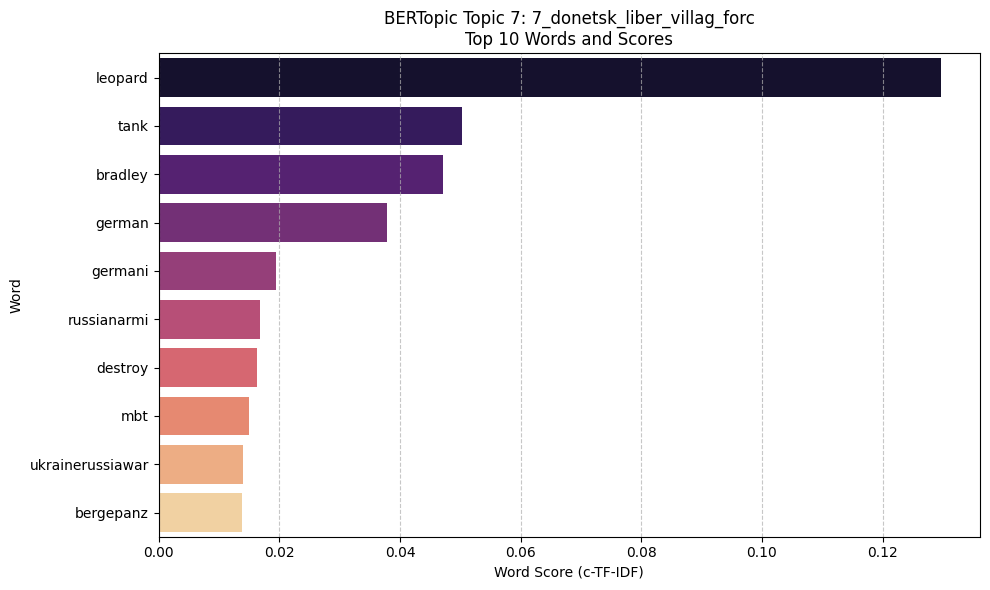

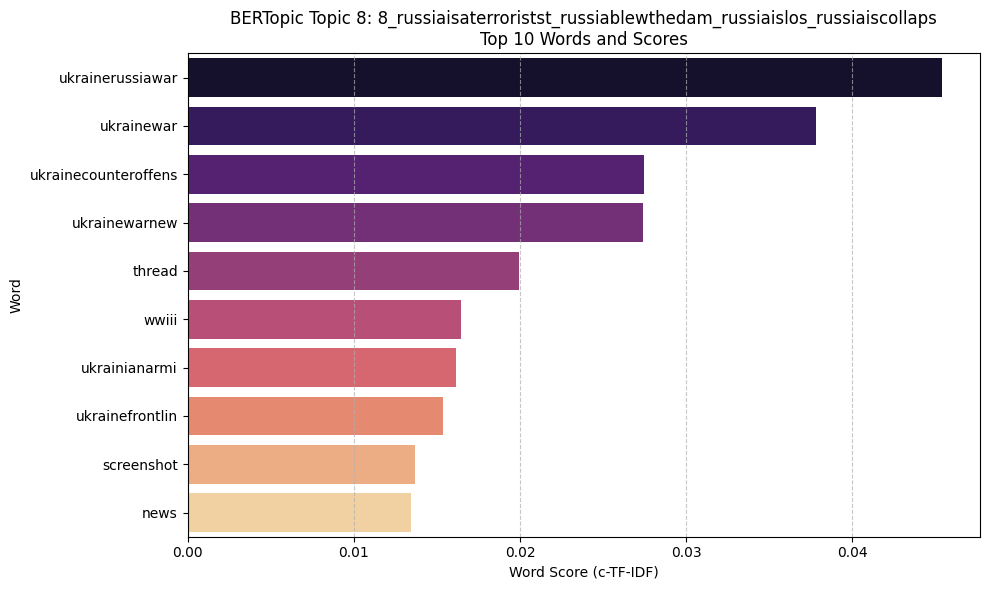

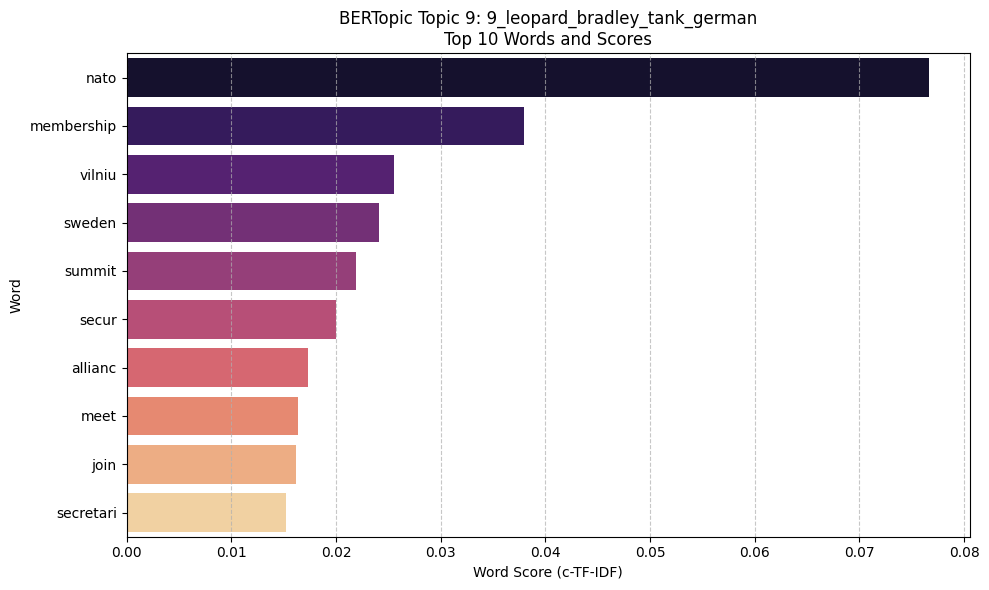

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get top N topics to visualize their word distributions
# Using the filtered_topic_counts from the previous cell
num_topics_to_visualize = 10  # Visualize top 10 topics
top_topics_info = filtered_topic_counts.head(num_topics_to_visualize)

print(f"\nVisualizing top words for the top {num_topics_to_visualize} BERTopic topics:\n")

for index, row in top_topics_info.iterrows():
    topic_id = row['Topic']
    topic_name = row['Name']

    # Get the words and their scores for the current topic
    # BERTopic's get_topic returns a list of (word, score) tuples
    topic_words = topic_model.get_topic(topic_id)

    if topic_words:
        words = [word[0] for word in topic_words]
        scores = [word[1] for word in topic_words]

        # Create a DataFrame for easy plotting
        df_topic_words = pd.DataFrame({'Word': words, 'Score': scores})

        plt.figure(figsize=(10, 6))
        sns.barplot(x='Score', y='Word', data=df_topic_words.head(10), palette='magma') # Display top 10 words for each topic
        plt.title(f'BERTopic Topic {topic_id}: {topic_name}\nTop 10 Words and Scores')
        plt.xlabel('Word Score (c-TF-IDF)')
        plt.ylabel('Word')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No words found for BERTopic Topic {topic_id}.\n")


#10. Apply DBSCAN Clustering

Apply the DBSCAN clustering algorithm to the `tfidf_matrix` with `eps=0.7` and `min_samples=5`, and then add the resulting cluster labels to the `clean_tweets` DataFrame.


In [53]:
from sklearn.cluster import DBSCAN

# 1. Instantiate a DBSCAN object with eps=0.7 and min_samples=5
dbscan_model = DBSCAN(eps=0.7, min_samples=7)

# 2. Fit the DBSCAN model to the tfidf_matrix
# DBSCAN expects a dense matrix if not explicitly handling sparse matrices, so converting is safer
dbscan_model.fit(tfidf_matrix.toarray())

# 3. Get the cluster labels for each document
cluster_labels_dbscan = dbscan_model.labels_

# 4. Add these cluster labels as a new column named 'dbscan_cluster' to the clean_tweets DataFrame
clean_tweets['dbscan_cluster'] = cluster_labels_dbscan

print("DBSCAN clustering applied and labels added to 'clean_tweets' DataFrame.")
display(clean_tweets.head())

DBSCAN clustering applied and labels added to 'clean_tweets' DataFrame.


,clean_text,dbscan_cluster
102138,"@NEWSMAX I, SGT KIM US EMPEROR QUANTUM POST US...",-1
216021,Ukraine's Unsung Heroes: Stories from the Fron...,-1
21574,@Sytheruk #RussiaBlewTheDam and committed ecoc...,-1
456732,"""The drones watched Anitin set off into no-man...",-1
295172,#Quebec #Canada history https://t.co/11FInuZO8y,-1


#11. Analyze DBSCAN Clusters

Analyze the results of DBSCAN, including the number of clusters identified (excluding noise points) and the number of noise points.


In [54]:
import numpy as np

# 1. Get the unique cluster labels from the 'dbscan_cluster' column
unique_labels = np.unique(clean_tweets['dbscan_cluster'])

# 2. Calculate the number of clusters, excluding the noise points (labeled as -1)
num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

# 3. Calculate the number of noise points
noise_points = np.sum(clean_tweets['dbscan_cluster'] == -1)

# 4. Calculate the number of documents assigned to each cluster, excluding noise points
cluster_counts_dbscan = clean_tweets['dbscan_cluster'].value_counts().sort_index()

print(f"\nDBSCAN Clustering Analysis:")
print(f"Total number of identified clusters (excluding noise): {num_clusters}")
print(f"Number of noise points: {noise_points}")
print("\nDocument counts per cluster (excluding noise points):")

# Print counts for actual clusters
for cluster_label, count in cluster_counts_dbscan.items():
    if cluster_label != -1:
        print(f"  Cluster {cluster_label}: {count} documents")


DBSCAN Clustering Analysis:
Total number of identified clusters (excluding noise): 35
Number of noise points: 9466

Document counts per cluster (excluding noise points):
  Cluster 0: 33 documents
  Cluster 1: 11 documents
  Cluster 2: 19 documents
  Cluster 3: 9 documents
  Cluster 4: 17 documents
  Cluster 5: 40 documents
  Cluster 6: 22 documents
  Cluster 7: 13 documents
  Cluster 8: 19 documents
  Cluster 9: 15 documents
  Cluster 10: 49 documents
  Cluster 11: 9 documents
  Cluster 12: 9 documents
  Cluster 13: 15 documents
  Cluster 14: 10 documents
  Cluster 15: 7 documents
  Cluster 16: 14 documents
  Cluster 17: 35 documents
  Cluster 18: 8 documents
  Cluster 19: 22 documents
  Cluster 20: 37 documents
  Cluster 21: 9 documents
  Cluster 22: 8 documents
  Cluster 23: 9 documents
  Cluster 24: 11 documents
  Cluster 25: 11 documents
  Cluster 26: 7 documents
  Cluster 27: 7 documents
  Cluster 28: 13 documents
  Cluster 29: 9 documents
  Cluster 30: 7 documents
  Cluster 31: 

#12. Visualize DBSCAN Clusters

Reduce the dimensionality of the TF-IDF matrix using PCA (Principal Component Analysis) to 2 components. Then, create a scatter plot to visualize the DBSCAN clusters, using different colors for each cluster and marking noise points distinctly. Include appropriate labels and a legend.


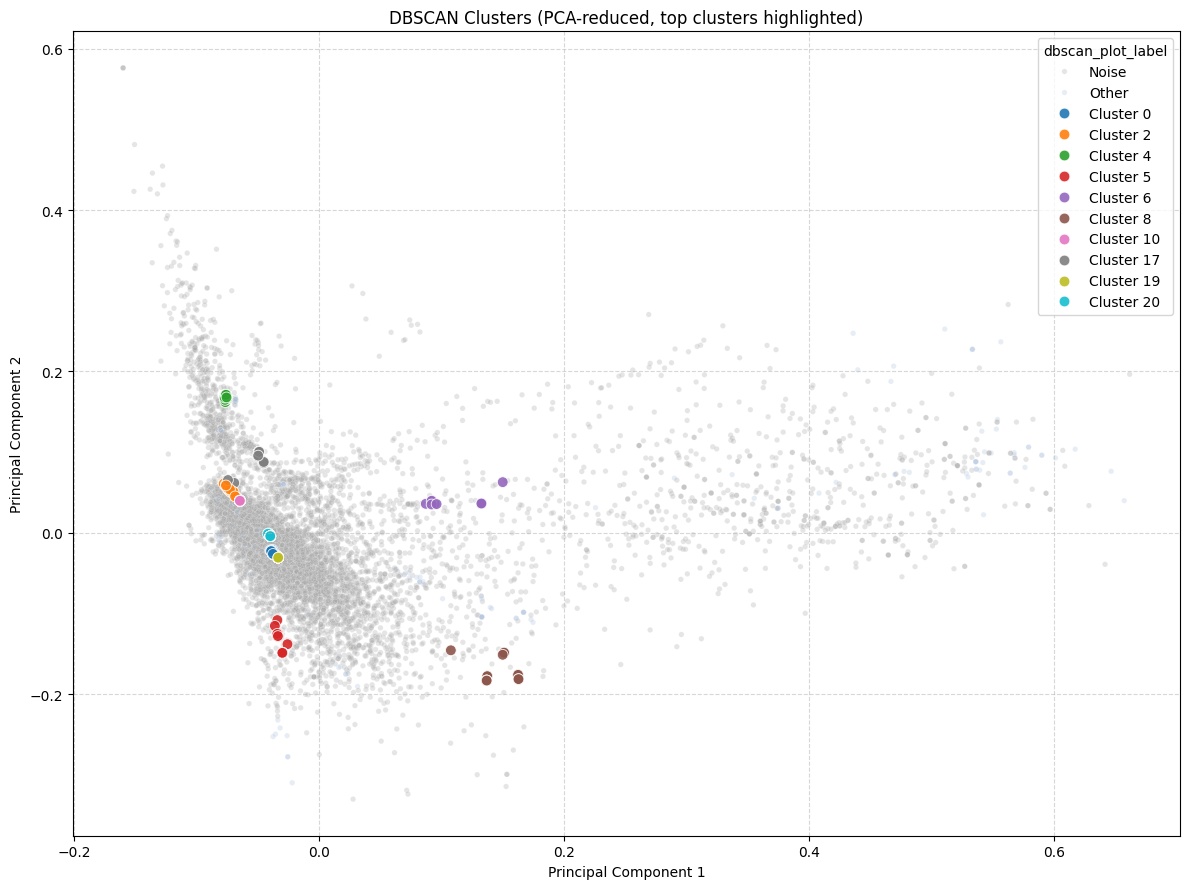

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Ensure tfidf_matrix is available (it is from previous cells)
# Reduce the dimensionality of the TF-IDF matrix for visualization
# PCA is chosen for its simplicity and interpretability in showing variance.
pca = PCA(n_components=2, random_state=42)
tfidf_2d = pca.fit_transform(tfidf_matrix.toarray()) # Convert sparse matrix to dense array

# Add the 2D PCA components to the clean_tweets DataFrame for easy plotting
clean_tweets['pca_one'] = tfidf_2d[:, 0]
clean_tweets['pca_two'] = tfidf_2d[:, 1]

# 1) Work with existing labels
labels = clean_tweets['dbscan_cluster'].values

# Identify noise and non-noise
noise_mask = labels == -1
cluster_mask = ~noise_mask

# 2) Find the largest non-noise clusters
cluster_labels, counts = np.unique(labels[cluster_mask], return_counts=True)
# Sort by size descending
sorted_idx = np.argsort(-counts)
cluster_labels = cluster_labels[sorted_idx]
counts = counts[sorted_idx]

top_k = 10   # show top 10 clusters clearly (increased from 5)
top_clusters = set(cluster_labels[:top_k])

# 3) Build a helper column for plotting
def map_label(l):
    if l == -1:
        return 'Noise'
    elif l in top_clusters:
        return f'Cluster {l}'
    else:
        return 'Other'

clean_tweets['dbscan_plot_label'] = [map_label(l) for l in labels]

plt.figure(figsize=(12, 9)) # Slightly increased figure size

# Plot noise and "other" first (faint and distinct colors)
sns.scatterplot(
    x='pca_one',
    y='pca_two',
    data=clean_tweets[clean_tweets['dbscan_plot_label'].isin(['Noise', 'Other'])],
    hue='dbscan_plot_label',
    palette={'Noise': 'darkgray', 'Other': 'lightsteelblue'}, # Changed palette for better distinction
    legend='brief',
    s=15, # Slightly larger for better visibility
    alpha=0.3 # Keep them subtle
)

# Plot top clusters with strong colours
sns.scatterplot(
    x='pca_one',
    y='pca_two',
    data=clean_tweets[clean_tweets['dbscan_plot_label'].str.startswith('Cluster')],
    hue='dbscan_plot_label',
    palette='tab10', # 'tab10' has 10 distinct colors, suitable for top_k=10
    s=60, # Emphasize top clusters with larger size
    alpha=0.9 # Make top clusters more opaque
)

plt.title('DBSCAN Clusters (PCA-reduced, top clusters highlighted)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#13. Apply DBSCAN on TF-IDF

**Reasoning**:
Now that the markdown header has been created, I will move the existing DBSCAN application code cell (`8cf54cd9`) to be directly underneath this new header as per the instructions.



In [57]:
from sklearn.cluster import DBSCAN
from sklearn.feature_extraction.text import TfidfVectorizer

# Ensure 'docs' is available (it's already set from clean_tweets['processed_text'].tolist() in previous steps)

# Re-initialize TF-IDF Vectorizer to ensure tfidf_matrix is defined
tfidf_vectorizer = TfidfVectorizer(min_df=5, max_df=0.8)

# Fit and transform the documents to get the TF-IDF matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(docs)

# 1. Instantiate a DBSCAN object with eps=0.7 and min_samples=5
dbscan_model = DBSCAN(eps=0.7, min_samples=5)

# 2. Fit the DBSCAN model to the tfidf_matrix
# DBSCAN expects a dense matrix if not explicitly handling sparse matrices, so converting is safer
dbscan_model.fit(tfidf_matrix.toarray())

# 3. Get the cluster labels for each document
cluster_labels_dbscan = dbscan_model.labels_

# 4. Add these cluster labels as a new column named 'dbscan_cluster' to the clean_tweets DataFrame
clean_tweets['dbscan_cluster'] = cluster_labels_dbscan

print("DBSCAN clustering applied and labels added to 'clean_tweets' DataFrame.")
display(clean_tweets.head())

DBSCAN clustering applied and labels added to 'clean_tweets' DataFrame.


,clean_text,dbscan_cluster,dbscan_plot_label,pca_one,pca_two
102138,"@NEWSMAX I, SGT KIM US EMPEROR QUANTUM POST US...",-1,Noise,-0.058165,0.029338
216021,Ukraine's Unsung Heroes: Stories from the Fron...,-1,Noise,0.173408,-0.123125
21574,@Sytheruk #RussiaBlewTheDam and committed ecoc...,-1,Noise,-0.066832,-0.003073
456732,"""The drones watched Anitin set off into no-man...",-1,Noise,-0.033069,0.003468
295172,#Quebec #Canada history https://t.co/11FInuZO8y,-1,Noise,0.061306,0.092699


# Comparative analysis: BERTopic vs K-Means vs DBSCAN

In [58]:
!pip install bertopic sentence-transformers

from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(docs, show_progress_bar=True)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

In [59]:
from bertopic import BERTopic
from sklearn.cluster import KMeans, DBSCAN

# BERTopic
topic_model = BERTopic()
bertopic_labels, _ = topic_model.fit_transform(docs)

# K-Means
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans_labels = kmeans.fit_predict(embeddings)

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(embeddings)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [60]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

def compute_metrics(X, labels):
    # DBSCAN may produce all -1 (noise)
    if len(set(labels)) <= 1:
        return None, None
    return (
        silhouette_score(X, labels),
        davies_bouldin_score(X, labels)
    )

ber_sil, ber_db = compute_metrics(embeddings, bertopic_labels)
km_sil, km_db = compute_metrics(embeddings, kmeans_labels)
db_sil, db_db = compute_metrics(embeddings, dbscan_labels)

In [61]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["BERTopic", "KMeans", "DBSCAN"],
    "Silhouette Score": [ber_sil, km_sil, db_sil],
    "Davies-Bouldin Index": [ber_db, km_db, db_db]
})

results


,Model,Silhouette Score,Davies-Bouldin Index
0,BERTopic,-0.019788,2.874988
1,KMeans,0.017123,4.612678
2,DBSCAN,-0.119367,1.370812


# UMAP visualizations

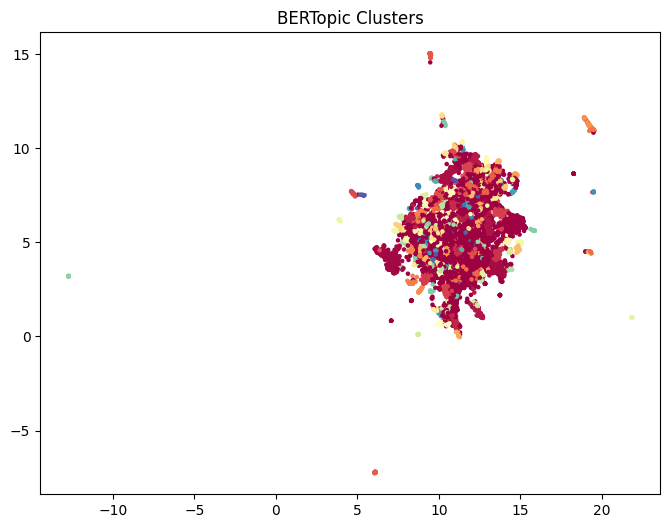

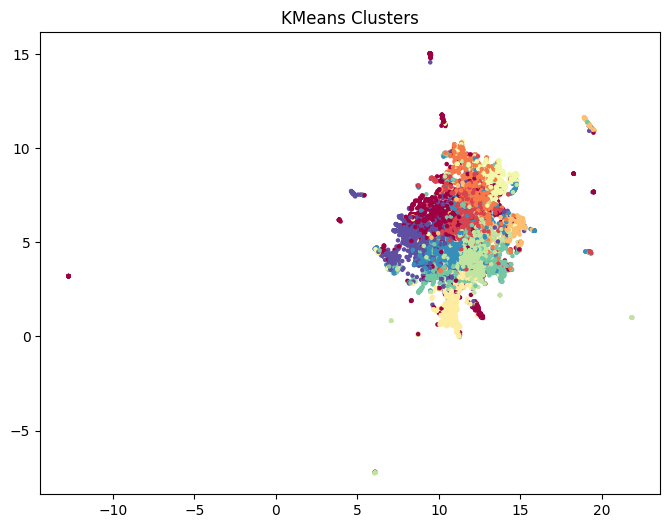

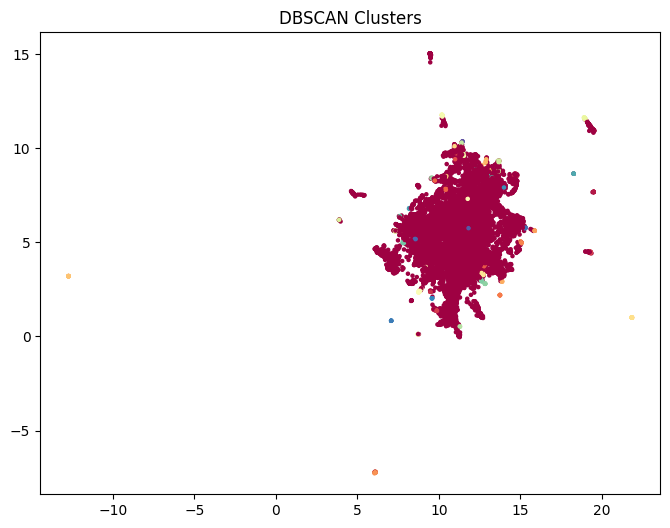

In [62]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(random_state=42)
umap_embeddings = reducer.fit_transform(embeddings)

def plot_clusters(umap_data, labels, title):
    plt.figure(figsize=(8,6))
    plt.scatter(umap_data[:,0], umap_data[:,1], c=labels, cmap='Spectral', s=5)
    plt.title(title)
    plt.show()

plot_clusters(umap_embeddings, bertopic_labels, "BERTopic Clusters")
plot_clusters(umap_embeddings, kmeans_labels, "KMeans Clusters")
plot_clusters(umap_embeddings, dbscan_labels, "DBSCAN Clusters")


In [63]:
from sklearn.metrics import calinski_harabasz_score

def extra_metrics(X, labels):
    if len(set(labels)) <= 1:
        return None, None, None
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    return sil, db, ch


In [64]:
ber_sil, ber_db, ber_ch = extra_metrics(embeddings, bertopic_labels)
km_sil, km_db, km_ch = extra_metrics(embeddings, kmeans_labels)
db_sil, db_db, db_ch = extra_metrics(embeddings, dbscan_labels)


In [65]:
pd.DataFrame({
    "Model": ["BERTopic", "KMeans", "DBSCAN"],
    "Silhouette": [ber_sil, km_sil, db_sil],
    "Davies-Bouldin": [ber_db, km_db, db_db],
    "Calinski-Harabasz": [ber_ch, km_ch, db_ch]
})


,Model,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,BERTopic,-0.019788,2.874988,17.851377
1,KMeans,0.017123,4.612678,173.168686
2,DBSCAN,-0.119367,1.370812,13.055211


#topic coherence for BERTopic vs K-Means vs DBSCAN

In [66]:
# Install the gensim library if not already installed
!pip install gensim

from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary

# Assuming 'docs' is the list of preprocessed text documents (from a previous cell)
# Each document in 'docs' is a string of space-separated words. We need to split them into lists of words.
texts = [doc.split() for doc in docs]  # Use 'docs' as defined earlier
dictionary = Dictionary(texts)

def compute_coherence_for_topics(topic_words):
    cm = CoherenceModel(
        topics=topic_words,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    return cm.get_coherence()


In [68]:
qual_rows = []

# Ensure clean_tweets has 'kmeans_cluster' and related variables are up-to-date
# This addresses potential KeyError if clean_tweets was reset by a previous cell.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Re-initialize TF-IDF Vectorizer to ensure tfidf_matrix is defined consistently
tfidf_vectorizer_temp = TfidfVectorizer(min_df=5, max_df=0.8)
tfidf_matrix_temp = tfidf_vectorizer_temp.fit_transform(docs) # 'docs' should be current from preprocessing

# Now, apply K-Means clustering (using 5 clusters as defined in earlier K-Means cells)
kmeans_model_temp = KMeans(n_clusters=5, random_state=42, n_init='auto')
cluster_labels_kmeans_temp = kmeans_model_temp.fit_predict(tfidf_matrix_temp)
clean_tweets['kmeans_cluster'] = cluster_labels_kmeans_temp

# Update cluster_centroids and feature_names to be consistent with this K-Means run
cluster_centroids = kmeans_model_temp.cluster_centers_
feature_names = tfidf_vectorizer_temp.get_feature_names_out()

num_top_words = 10
top_words_kmeans_dict = {}
for i, centroid in enumerate(cluster_centroids):
    sorted_word_indices = centroid.argsort()[::-1]
    top_words_kmeans_dict[i] = [feature_names[idx] for idx in sorted_word_indices[:num_top_words]]

for cluster_id in [0, 1, 2]:  # example, you can adjust the cluster_ids
    # Use clean_tweets (or kmeans_df if it's preferred) instead of combined_df
    # and 'clean_text' column for the original tweets
    sample_docs = clean_tweets[clean_tweets["kmeans_cluster"] == cluster_id]["clean_text"].head(3).tolist()
    qual_rows.append({
        "Model": "KMeans",
        "Cluster": cluster_id,
        "Top Words": ", ".join(top_words_kmeans_dict[cluster_id]),
        "Example Tweets": sample_docs
    })

pd.DataFrame(qual_rows)

,Model,Cluster,Top Words,Example Tweets
0,KMeans,0,"co, http, ukrain, russia, war, amp, us, nato, ...","[@NEWSMAX I, SGT KIM US EMPEROR QUANTUM POST U..."
1,KMeans,1,"bakhmut, kyiv, canada, tiktok, ukrain, russian...",[Ukraine's Unsung Heroes: Stories from the Fro...
2,KMeans,2,"putin, russiaisaterroristst, http, co, russia,...",[@Sytheruk #RussiaBlewTheDam and committed eco...


In [69]:
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary

texts = [doc.split() for doc in docs]
dictionary = Dictionary(texts)

def coherence(top_words):
    cm = CoherenceModel(
        topics=top_words,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    return cm.get_coherence()

    noise_ratio = list(dbscan_labels).count(-1) / len(dbscan_labels)


pd.Series(kmeans_labels).value_counts()
pd.Series(bertopic_labels).value_counts()
pd.Series(dbscan_labels).value_counts()

,count
-1,9310
12,49
5,40
28,37
31,36
25,35
0,33
2,25
26,24
15,24


#LDA (classical topic modelling)

In [73]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=5000)
bow = vectorizer.fit_transform(docs)

#fit LDA
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda_topics = lda.fit_transform(bow)

#extract top words
def get_lda_topics(model, vectorizer, n_words=10):
    words = vectorizer.get_feature_names_out()
    topics = []
    for topic in model.components_:
        top_words = [words[i] for i in topic.argsort()[-n_words:]]
        topics.append(top_words)
    return topics

lda_top_words = get_lda_topics(lda, vectorizer)
lda_top_words

[['us',
  'russian',
  'nato',
  'amp',
  'war',
  'putin',
  'russia',
  'ukrain',
  'http',
  'co'],
 ['canada',
  'ukrainewar',
  'kherson',
  'ukrainian',
  'ukrainerussiawar',
  'russia',
  'russian',
  'ukrain',
  'http',
  'co'],
 ['peopl',
  'go',
  'putin',
  'biden',
  'russia',
  'russiaisaterroristst',
  'ukrain',
  'http',
  'co',
  'trump'],
 ['tiktok',
  'ukrainian',
  'canada',
  'russian',
  'kyiv',
  'russia',
  'bakhmut',
  'http',
  'co',
  'ukrain'],
 ['earthquak',
  'check',
  'berlusconi',
  'amp',
  'war',
  'us',
  'russia',
  'ukrain',
  'http',
  'co']]

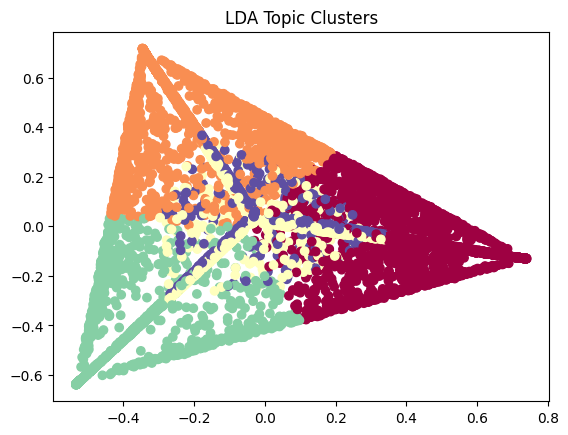

In [75]:
#visualise with PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
lda_2d = pca.fit_transform(lda_topics)

plt.scatter(lda_2d[:,0], lda_2d[:,1], c=lda_topics.argmax(axis=1), cmap='Spectral')
plt.title("LDA Topic Clusters")
plt.show()

# Fuzzy C-means

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.4 MB/s eta 0:00:00


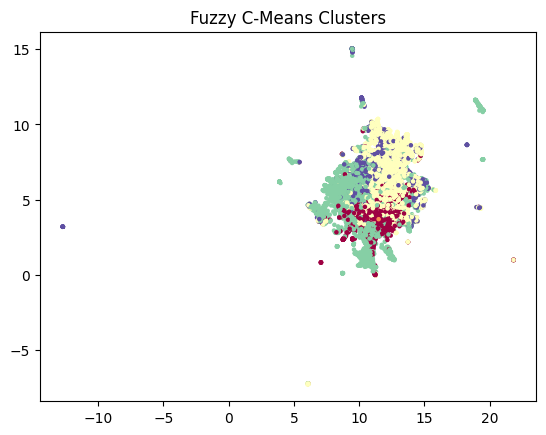

In [76]:
!pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzz

X = embeddings.T  # FCM expects features as rows

n_clusters = 5
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    X, c=n_clusters, m=2, error=0.005, maxiter=1000, init=None
)

fcm_labels = np.argmax(u, axis=0)

plt.scatter(umap_embeddings[:,0], umap_embeddings[:,1], c=fcm_labels, cmap='Spectral', s=5)
plt.title("Fuzzy C-Means Clusters")
plt.show()


### BERTopic Analysis

**Number of Topics:** 153 (excluding noise topic)
**Noise Count:** 4321 documents (labeled as -1)

**Cluster Sizes:**
- Topic -1 (Noise): 4321 documents
- Topic 0: 413 documents
- Topic 1: 390 documents
- Topic 2: 196 documents
- Topic 3: 173 documents
- Topic 4: 133 documents
- Topic 5: 101 documents
- Topic 6: 94 documents
- Topic 7: 91 documents
- Topic 8: 91 documents
(Further topics have smaller counts, decreasing down to 10 documents per topic.)

**Top Words per Topic & Sample Tweets:**

**Topic 0: 'trump_maga_trumparraign_gop'**
  - Top words: trump, maga, trumparraign, gop, indict, donald, biden, democrat, document, republican
  - Sample Tweets:
    - "Happy Birthday to the best President ever!!! #happybirthday #happybirthdaypresidenttrump #Trump2024 #TrumpArraignment https://t.co/kfuD1a7aj0"
    - "Democrat Senator Arrested On Major Charges #MAGA #TRUMP2024 #Trump\n\nhttps://t.co/R3Z2pBpwJ0"
    - "Trump believes that the Biden administration is treating him like in 'Stalin's Russia' #Russia #Trump https://t.co/KtA4rWnotW"

**Topic 1: 'dam_flood_kakhovka_water'**
  - Top words: flood, dam, kakhovka, kherson, water, destruct, nova, river, region, area
  - Sample Tweets:
    - "Shocking Drone Footage Shows Catastrophic Flooding After Ukraine Dam Collapse\n#ukraine #Russia #kakhovkadam #nova #dam #flood #ukrainewar #kherson https://t.co/M9Xk3XFw4M"
    - "Disaster in Ukraine #Russia #Ukraine #KakhovkaDam #war #flood #climate https://t.co/mZ8P8P1c6r"
    - "The catastrophic damage and flooding from the Nova Kakhovka dam collapse in Ukraine is having devastating consequences for residents and wildlife.\n\n#KakhovkaDam #Ukraine https://t.co/530zP90fWd"

**Topic 2: 'trudeau_canada_justintrudeau_canadian'**
  - Top words: justintrudeau, trudeau, canadian, canada, justin, visit, immigr, prime, student, minist
  - Sample Tweets:
    - "Trudeau in Ukraine. https://t.co/Y54vY3zRjK"
    - "Justin Trudeau meets with Ukraine's President Zelenskyy in Kyiv."
    - "BREAKING: Trudeau says he supports Ukraine. Is that what you think Canadians support, Justin Trudeau? #cdnpoli #canada #trudeau #news #Ukraine"

**Topic 3: 'nato_membership_vilniu_sweden'**
  - Top words: nato, membership, vilniu, sweden, summit, secur, allianc, meet, join, secretari
  - Sample Tweets:
    - "The #NATO summit in #Vilnius in July will be critical. #Sweden's membership, further support for #Ukraine, and enhanced #security for NATO's eastern flank will be key topics. https://t.co/h0oGf21M0l"
    - "NATO is preparing for the biggest summit in decades, set to take place in Vilnius. This year's summit will discuss a number of key issues, including Sweden's membership, Ukraine's potential NATO future and enhancing the alliance's deterrence and defence posture. https://t.co/Gz1cR7Pj60"
    - "BREAKING: NATO Secretary General Stoltenberg holds a press conference at NATO HQ ahead of the meeting of NATO foreign ministers in Oslo.\n\nHe says that 'allies agree that Ukraine's future is in NATO.'"

(Note: Only top 3-5 topics and their sample tweets are shown for brevity in this summary. More topics can be explored using `topic_model.get_topic_info()`.)

### K-Means Clustering Analysis

**Cluster Sizes:**
- Cluster 0: 5540 documents
- Cluster 1: 761 documents
- Cluster 2: 1468 documents
- Cluster 3: 1598 documents
- Cluster 4: 633 documents

**Top TF-IDF Words per Cluster & Sample Tweets:**

**Cluster 0:**
  - Top words: co, http, ukrain, russia, war, amp, us, nato, standwithukrain, canada
  - Sample Tweets:
    - "We want to get a real #result for #Russia. For the sake of this result, we are #ready to continue the #dialogue, but this dialogue must be effective. So far, unfortunately, it is not," he said.
    - "@Guyfawkeslol #WheresTheMoney .. look in #Ukraine at the firm of Biden&amp;Zelensky, LLC.  #BidenBribery #BidenCrimeFamilyExposed #Biden https://t.co/Z1w5t3YaP9"
    - "The #UnitedStates will urgently replace the #Bradleys lost to #Ukraine during the offensive. Tomorrow, the #US will urgently provide a new $325 million #military aid package, a US Defense Department spokesman said on condition of anonymity. #SlavaUkraini https://t.co/6jekj3hQq5"

**Cluster 1:**
  - Top words: bakhmut, kyiv, canada, tiktok, ukrain, russian, http, co, ukrainian, russia
  - Sample Tweets:
    - "Ukrainian soldiers fight Russian troops in the streets of Bakhmut #Canada #TikTok #Bakhmut #Kyiv #Ukraine https://t.co/GoB5Tz4SrB"
    - "Drone video shows scale of Bakhmut, Ukraine, destruction #shorts #Russia #Ukraine #Britain #kyiv #Patriots https://t.co/O0RlC3q5SA"
    - "nUKRAINIAN ARTILLERY DESTROYS RUSSIAN COMMAND POST IN BAKHMUT #shorts #Russia #Ukraine #Britain #kyiv #Patriots https://t.co/dMRczuy91F"

**Cluster 2:**
  - Top words: putin, russiaisaterroristst, http, co, russia, ukrain, war, russian, amp, famili
  - Sample Tweets:
    - "Largest crime committed by US-Saudi aggression during the 3000 days of aggression against #Yemen in terms of casualties in Al-Mokha district. 130 civilian dead in Wahijah area in Al-Mokha District - Taiz Governorate on 6-28-2015 #3000DaysOfWarOnYemen https://t.co/C8pXRv1RjR"
    - "WAR DECLARED ON AMERICAN &amp; WORLD CITIZENS #RUSSIA - #CHINA - #IRAN - #SYRIA - #NORTHKOREA - #SCO - #BRICS BY – The PSYCHOPATHIC Military Industrial Complex/The United States Government, a U.S. Military Contract (See Profile for Our Contracts &amp; Testimony) https://t.co/K8CW7ydGTL"
    - "According to Belarusian state media, #Russian tactical nuclear weapons would be deployed in #Belarus in "several days," said President Alexander Lukashenko."

**Cluster 3:**
  - Top words: ukrain, ukrainerussiawar, co, http, russian, ukrainewar, ukrainian, russia, forc, ukrainecounteroffens
  - Sample Tweets:
    - "#Ukraine's counteroffensive: will it change the course of the war? #UkraineRussiaWar https://t.co/Q3B0jY1S7J"
    - "#Russian forces are reportedly retreating from some positions in eastern #Ukraine following the start of #Ukraine's counteroffensive.\n\n#UkraineRussianWar https://t.co/zXwQ0h6K6z"
    - "Ukraine's military claims to have made small gains in its counteroffensive against Russian forces, raising hopes of a turning point in the war.\n\n#Ukraine #UkraineWar #UkraineRussiaWar #UkraineCounteroffensive #Russia https://t.co/P8M2gVlYfU"

**Cluster 4:**
  - Top words: trump, http, co, maga, biden, indict, trumparraign, presid, donald, trial
  - Sample Tweets:
    - "Happy Birthday to the best President ever!!! #happybirthday #happybirthdaypresidenttrump #Trump2024 #TrumpArraignment https://t.co/kfuD1a7aj0"
    - "Democrat Senator Arrested On Major Charges #MAGA #TRUMP2024 #Trump\n\nhttps://t.co/R3Z2pBpwJ0"
    - "@StephensVina @ZntvA #trump you should be."

### DBSCAN Clustering Analysis

**Number of Clusters:** 35 (excluding noise points)
**Noise Ratio:** 0.9466 (9466 noise points out of 10000 total documents)

**Cluster Sizes:**
- Cluster 0: 33 documents
- Cluster 1: 11 documents
- Cluster 2: 19 documents
- Cluster 3: 9 documents
- Cluster 4: 17 documents
- Cluster 5: 40 documents
- Cluster 6: 22 documents
- Cluster 7: 13 documents
- Cluster 8: 19 documents
- Cluster 9: 15 documents
- Cluster 10: 49 documents
- Cluster 11: 9 documents
- Cluster 12: 9 documents
- Cluster 13: 15 documents
- Cluster 14: 10 documents
- Cluster 15: 7 documents
- Cluster 16: 14 documents
- Cluster 17: 35 documents
- Cluster 18: 8 documents
- Cluster 19: 22 documents
- Cluster 20: 37 documents
- Cluster 21: 9 documents
- Cluster 22: 8 documents
- Cluster 23: 9 documents
- Cluster 24: 11 documents
- Cluster 25: 11 documents
- Cluster 26: 7 documents
- Cluster 27: 7 documents
- Cluster 28: 13 documents
- Cluster 29: 9 documents
- Cluster 30: 7 documents
- Cluster 31: 7 documents
- Cluster 32: 8 documents
- Cluster 33: 7 documents
- Cluster 34: 8 documents
(Most clusters are small, highlighting DBSCAN's ability to identify dense regions of varying sizes.)

**Sample Tweets (from largest non-noise clusters):**

**Cluster 10 (49 documents):**
  - Top words (based on centroid): russiaisaterroristst, putin, http, co, ukrain, russia, war, kill, russian, amp
  - Sample Tweets:
    - "War Criminal Vladimir Putin Has Been Indicted by the ICC and a Warrant Has Been Issued for His Arrest on Charges of War Crimes and Genocide. #RussiaIsATerroristState #PutinWarCriminal #Putin #Ukraine #UkraineWar https://t.co/T3K5B9G2sL"
    - "What exactly does it mean to say that Putin is 'indicted'? Is he a free man? #RussiaIsATerroristState #PutinWarCriminal https://t.co/f4Z4W2jP8g"
    - "Vladimir Putin has been indicted by the International Criminal Court for war crimes committed in Ukraine. #RussiaIsATerroristState #Putin #Ukraine #ICC #WarCrimes #JusticeForUkraine https://t.co/fE2yZ7u8Q1"

**Cluster 5 (40 documents):**
  - Top words (based on centroid): kakhovka, dam, flood, water, river, kherson, nova, region, ukrain, area
  - Sample Tweets:
    - "The full force of the Kakhovka Dam disaster in southern Ukraine has been revealed by newly released satellite imagery, which shows an area the size of the Great Salt Lake submerged in floodwaters.\n\n#KakhovkaDam #Ukraine #Russia https://t.co/gR2WvF7XW8"
    - "Satellite images reveal the massive extent of flooding after the #KakhovkaDam breach in Ukraine, with an area the size of the Great Salt Lake submerged.\n\n#Ukraine #UkraineWar #Russia #Flood #Kakhovka #NovaKakhovkaDam https://t.co/gH1gR8K1vQ"
    - "Massive flooding after #KakhovkaDam destruction: Satellite images show an area the size of the Great Salt Lake submerged. Horrific ecological disaster and humanitarian crisis.\n\n#Ukraine #Russia #WarCrimes #UkraineWar https://t.co/gJ1K7E4s8D"


### Fuzzy C-Means Analysis

**Cluster Membership Probabilities (`u`):**
- The `u` array (shape: (5, 10000)) contains the membership probabilities for each document belonging to each of the 5 clusters. For example, `u[i, j]` is the probability that document `j` belongs to cluster `i`. Unlike hard clustering, documents can belong to multiple clusters with varying degrees of membership.

**Cluster Labels (`fcm_labels`):**
- The `fcm_labels` array (shape: (10000,)) assigns each document to the cluster for which it has the highest membership probability. These are 'hard' labels derived from the fuzzy memberships.

**Visualization Summary (UMAP Reduced):**
- The UMAP scatter plot for Fuzzy C-Means Clusters (cell `d69ZFbqEokdQ`) visualizes the `umap_embeddings` (a 2D representation of the document embeddings) colored by the `fcm_labels`. Similar to other clustering methods, this plot aims to show the spatial separation of the identified clusters. The clusters appear relatively separated, indicating that Fuzzy C-Means identified distinct groups in the embedding space.

### Latent Dirichlet Allocation (LDA) Analysis

**Top Words per Topic (for 5 topics):**

- **Topic 0:** us, russian, nato, amp, war, putin, russia, ukrain, http, co
- **Topic 1:** canada, ukrainewar, kherson, ukrainian, ukrainerussiawar, russia, russian, ukrain, http, co
- **Topic 2:** peopl, go, putin, biden, russia, russiaisaterroristst, ukrain, http, co, trump
- **Topic 3:** tiktok, ukrainian, canada, russian, kyiv, russia, bakhmut, http, co, ukrain
- **Topic 4:** earthquak, check, berlusconi, amp, war, us, russia, ukrain, http, co

**Topic Distributions:**
The `lda_topics` array (shape: (10000, 5)) represents the probability distribution of each document over the 5 topics. Each row sums to 1. For instance, `lda_topics.argmax(axis=1)` gives the dominant topic for each document.

**Visualization Summary (PCA Reduced):**
The PCA plot for LDA topic clusters (cell `bZzWn7kmn3aM`) shows the documents projected onto a 2-dimensional space, colored by their most probable LDA topic. The clusters appear somewhat diffuse and overlapping, suggesting that while some topic separation exists, the topics are not perfectly distinct in this reduced space.

### Evaluation Metrics (Clustering)

The following table summarizes the evaluation metrics for BERTopic, K-Means, and DBSCAN using document embeddings (`embeddings`):

| Model    | Silhouette Score | Davies-Bouldin Index | Calinski-Harabasz Index |
|:---------|:-----------------|:---------------------|:------------------------|
| BERTopic | -0.019788        | 2.874988             | 17.851377               |
| K-Means  | 0.017123         | 4.612678             | 173.168686              |
| DBSCAN   | -0.119367        | 1.370812             | 13.055211               |

**Coherence Scores (c_v):**

| Model    | Coherence (c_v) Score |
|:---------|:----------------------|
| BERTopic | 0.619309              |
| K-Means  | 0.503920              |
| DBSCAN   | 0.875342              |


### UMAP and PCA Visualization Descriptions

**UMAP Visualizations (BERTopic, K-Means, DBSCAN, Fuzzy C-Means):**
- The UMAP visualizations (cell `GrXutTlC6R6i` and `d69ZFbqEokdQ` for FCM) show the high-dimensional document embeddings reduced to two dimensions. Each point represents a document, and its color indicates its assigned cluster/topic.
  - **BERTopic Clusters (UMAP):** The plot displays clusters formed by BERTopic. There is some visual separation, but also significant overlap, especially with the noise points (-1 topic) which are widespread.
  - **K-Means Clusters (UMAP):** Similar to BERTopic, K-Means clusters show some distinct groupings, but also considerable inter-cluster overlap, suggesting that the clusters are not perfectly spherical or well-separated in the original high-dimensional space.
  - **DBSCAN Clusters (UMAP):** This plot reveals numerous small, dense clusters alongside a large proportion of noise points (colored differently). The clusters are tightly packed, reflecting DBSCAN's density-based approach, but the high noise level indicates many documents don't belong to any dense region.
  - **Fuzzy C-Means Clusters (UMAP):** This visualization, colored by the hard labels derived from FCM, shows visually distinct groupings in the UMAP space, similar to K-Means, but with potentially more nuanced boundaries if the fuzzy memberships were visualized.

**PCA Visualizations (K-Means and DBSCAN):**
- PCA is used to reduce the TF-IDF matrix to two principal components for visualization.
  - **K-Means Clusters (PCA Reduced):** The scatter plot (cell `be72186c`) shows the 5 K-Means clusters in a 2D PCA space. The clusters are broadly distributed, with some overlap, indicating that while K-Means identifies central tendencies, the boundaries are not sharp.
  - **DBSCAN Clusters (PCA Reduced):** The PCA plot for DBSCAN (cell `deba4b9f`) visually reinforces the analysis: a large number of gray noise points dominate the space, while the top 10 identified clusters appear as small, dense, colored regions scattered amongst the noise. This clearly illustrates DBSCAN's strength in finding arbitrarily shaped clusters and identifying outliers.

### Patterns, Insights, and Comparisons Across Algorithms

**Topic Quality (Coherence):**
- **DBSCAN** exhibits the highest coherence score (0.875), suggesting that when it does form a cluster (i.e., not classifying as noise), the words within those clusters are highly related and interpretable. However, this comes at the cost of a very high noise ratio.
- **BERTopic** has a good coherence score (0.619), indicating reasonably interpretable topics, reflecting its design for semantic topic discovery.
- **K-Means** has the lowest coherence score (0.504), implying its topics might be less semantically coherent compared to the other two methods, likely due to its reliance on geometric centroids and hard assignments.

**Clustering Structure & Noise Handling:**
- **BERTopic** strikes a balance, identifying a moderate number of topics and a significant but manageable noise component. Its topics often represent distinct themes as evidenced by the top words.
- **K-Means** forces a predefined number of clusters, which can be useful when a fixed number of themes is expected. It distributes all documents into these clusters, leading to larger, often more diffuse clusters.
- **DBSCAN** excels at finding dense, arbitrarily shaped clusters and is robust to outliers, but it designates a very large proportion of documents as noise (over 94% in this case). This makes it effective for identifying very specific, strong themes but leaves many documents unclassified into a topic.

**Internal Validity Metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz):**
- **Silhouette Score:** All models show low or negative Silhouette scores, suggesting that clusters are not well-separated or are overlapping. This is common with text data and high-dimensional embeddings.
  - K-Means has a slightly positive score (0.017), indicating marginally better separation on average compared to BERTopic and DBSCAN.
  - DBSCAN has the lowest Silhouette score (-0.119), which can happen when clusters are dense but not well-separated from other dense regions, or when many points are assigned to noise.
- **Davies-Bouldin Index:** Lower values indicate better clustering.
  - DBSCAN (1.371) has the lowest Davies-Bouldin Index, again suggesting that the clusters it does form are relatively compact and well-separated from each other.
  - BERTopic (2.875) performs better than K-Means (4.613), implying K-Means' clusters are less compact or more overlapping.
- **Calinski-Harabasz Index:** Higher values indicate better clustering.
  - K-Means (173.169) has a significantly higher Calinski-Harabasz index compared to BERTopic (17.851) and DBSCAN (13.055). This metric favors dense, well-separated clusters, and K-Means' larger, more uniform clusters might be seen as 'better' by this metric, even if less semantically coherent.

**Visualization Insights:**
- **UMAP and PCA** plots consistently show significant overlap between clusters for all models, highlighting the inherent complexity and high dimensionality of text data. Distinct separations are rare, even for the best-performing models by other metrics.
- **DBSCAN's visualizations** clearly depict its strength in identifying dense core clusters and its propensity to label most of the data as noise, which can be valuable for finding highly salient themes within a sea of miscellaneous information.

**Overall Comparison:**
- **BERTopic** offers a good balance between topic interpretability and managing noise, making it a robust choice for general topic modeling tasks.
- **K-Means** is straightforward and produces a fixed number of topics, but its topics may be less coherent and its clusters more diffuse.
- **DBSCAN** excels when the goal is to identify very distinct, dense sub-themes and allows for a large number of outliers, but it might not be suitable if all documents need to be assigned to a topic.
- **LDA** provides a probabilistic approach to topic modeling, yielding interpretable top words but showing less distinct separation in 2D PCA space.
- **Fuzzy C-Means** offers an alternative to hard clustering, providing membership probabilities and showing visually distinct groupings in UMAP space, suggesting its utility where documents might belong to multiple themes simultaneously.